Введение: «Kick Driver» - сервис аренды самокатов. Для повышения прибыльности проекта руководство компании хочет внедрить динамическую систему определения стоимости поездки. Необходимо проанализировать имеющиеся данные и сделать выводы об определяющих объем спроса факторах, на которые необходимо обратить внимание при формировании такой системы.

# IMPORT

In [4]:
import os
from dotenv import load_dotenv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, kruskal, normaltest
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler

load_dotenv()
path = os.getenv('DATA_PATH')

У нас есть два исходных файла. Для начала нам нужно провести предобработку этих 2-ух файлов, а потом уже на подготовленных данных делать какие то выводы, смотреть, анализировать

# rides.csv

In [5]:
df_r = pd.read_csv(os.path.join(path, 'rides.csv'), sep=',', encoding='UTF-8')

## Предобработка данных

### PEP-8 и типы данных

Сперва нам следует привести в порядок название факторов, типы данных факторов. Приводим названия к PEP-8, типы данных к соответствующим.

In [6]:
df_r.columns = df_r.columns.str.lower().str.replace(' ', '_')
df_r.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              102255 non-null  int64  
 1   start_date      102255 non-null  object 
 2   end_date        102255 non-null  object 
 3   start_location  102255 non-null  object 
 4   start_district  102255 non-null  object 
 5   end_location    102255 non-null  object 
 6   end_district    102255 non-null  object 
 7   distance        101022 non-null  float64
 8   promo           102255 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 7.0+ MB


In [7]:
df_r['start_date'] = pd.to_datetime(df_r['start_date'])
df_r['end_date'] = pd.to_datetime(df_r['end_date'])

Перевели к PEP-8, исправили тип данных на datetime у временных факторов.

### Дубликаты

Предобработка дубликатов - очень значимый момент, тут нужно понимать что это сильно влияет на статистику и нужно решить этот вопрос

#### Явные дубликаты

In [8]:
df_r.duplicated().sum()

np.int64(4883)

In [9]:
df_r.duplicated().mean()

np.float64(0.047753166104346975)

In [10]:
dups = df_r[df_r.duplicated(keep=False)]

In [11]:
dups.sort_values('id').head(10)

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo
16,100356,2023-04-22 09:44:41,2023-04-22 10:23:10,Энтузиастов,Центральный,Сиреневая,Юго-Восточный,4715.0,0
17,100356,2023-04-22 09:44:41,2023-04-22 10:23:10,Энтузиастов,Центральный,Сиреневая,Юго-Восточный,4715.0,0
45,100383,2023-04-22 10:33:56,2023-04-22 10:58:41,Ломоносова,октябрьский,ул. матросова,Центральный,3907.0,0
44,100383,2023-04-22 10:33:56,2023-04-22 10:58:41,Ломоносова,октябрьский,ул. матросова,Центральный,3907.0,0
81,100419,2023-04-22 11:31:18,2023-04-22 12:03:19,Цветочная,северо-западный,Коммунальная,Юго-Восточный,4801.0,0
82,100419,2023-04-22 11:31:18,2023-04-22 12:03:19,Цветочная,северо-западный,Коммунальная,Юго-Восточный,4801.0,0
100,100436,2023-04-22 12:06:27,2023-04-22 12:34:24,Пионерская,Заречный,Первомайская,Северо-Западный,3721.0,0
99,100436,2023-04-22 12:06:27,2023-04-22 12:34:24,Пионерская,Заречный,Первомайская,Северо-Западный,3721.0,0
107,100442,2023-04-22 12:14:49,2023-04-22 12:37:10,Комсомольская,Заречный,Луговая,Октябрьский,3171.0,0
106,100442,2023-04-22 12:14:49,2023-04-22 12:37:10,Комсомольская,Заречный,Луговая,Октябрьский,3171.0,0


In [12]:
df_r[df_r.duplicated(keep=False)].shape

(9766, 9)

видим что строки сдвоены, 4883 дубликатов, 9766 наблюдений

In [13]:
df_r.drop_duplicates().head(10)

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,Лесная,Юго-Восточный,Западная,Ленинский,4879.0,0
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,Пролетарская,Центральный,Свободы,Ленинский,1846.0,0
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,Комарова,Ленинский,ул. западная,Ленинский,3133.0,0
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,Западная,ленинский,Озерная,Юго-Восточный,3.0,0
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,Свободы,ленинский,ул. чкалова,юго-восточный,5263.0,0


Строки были сдублированы, нам это удалось решить, от явных дубликатов избавились, далее неявные.

#### Неявные дубликаты

In [14]:
df_r['start_location'].unique()

array(['Шевченко', 'Чехова', 'Буденного', 'Труда', 'Первомайская',
       'Лесная', 'Пролетарская', 'Комарова', 'Западная', 'Свободы',
       'Коммунальная', 'Зеленая', 'Шоссейная', 'Центральная', 'буденного',
       'новая', 'Энтузиастов', 'ул.подгорная', 'Восточная', 'Лермонтова',
       'Школьная', 'Пушкина', 'подгорная', 'рябиновая', 'Солнечная',
       'Мичурина', 'ул труда', 'Партизанская', 'Вокзальная',
       'Комсомольская', 'майская', 'Красноармейская', 'Рабочая',
       'Почтовая', 'дачная', 'Заводская', 'Ломоносова', 'карла маркса',
       'Советская', 'Красная', 'Дзержинского', 'Рябиновая',
       'ул.советская', 'ул.энергетиков', 'Пионерская', 'ленина',
       'ул. сиреневая', 'гагарина', 'юбилейная', 'Цветочная',
       'ул. набережная', 'Сосновая', 'Спортивная', 'Новая', 'Ленина',
       'Полевая', 'ул. строительная', 'Майская', 'Озерная', 'ул.горького',
       'ул. восточная', 'пионерская', 'Энергетиков', 'ул.озерная',
       'южная', 'Некрасова', 'ул.молодежная', 'ул.

Если изучить то можно понять что тут записано 3 версии каждой из улиц, например: Буденного буденного ул.буденного

In [15]:
def clean_loc(col):
    return (
        col.str.strip()
        .str.lower()
        .str.replace(r'^ул\.?\s*', '', regex=True)
        .str.replace(r'\s+', '', regex=True)
    )


df_r['start_location'] = clean_loc(df_r['start_location'])
df_r['end_location'] = clean_loc(df_r['end_location'])

In [16]:
def clean_district(col):
    return (
        col.str.strip()
        .str.lower()
        .str.replace(r'северозападный', 'северо-западный', regex=True)
        .str.replace(r'северо западный', 'северо-западный', regex=True)
    )


df_r['end_district'] = clean_district(df_r['end_district'])
df_r['start_district'] = clean_district(df_r['start_district'])

По итогам мы выявили 2 типа дубликатов в этом датафрейме.
- **Явные:** мы заметили что их 4% (4883 наблюдения) - исправили.
- **Неявные:** присмотревшись к датафрейму поподробнее, можно заметить что неявные дубликаты тоже есть, как, например, в факторе 'start_location' одна улица записана в 3 разных формах, в подобных факторах идентично. Написали функцию которая будет исправлять этот момент - исправили.

### Выбросы

Основная цель этого раздела: провести первичный анализ количественных шкал, ориентированный на выявление выбросов.

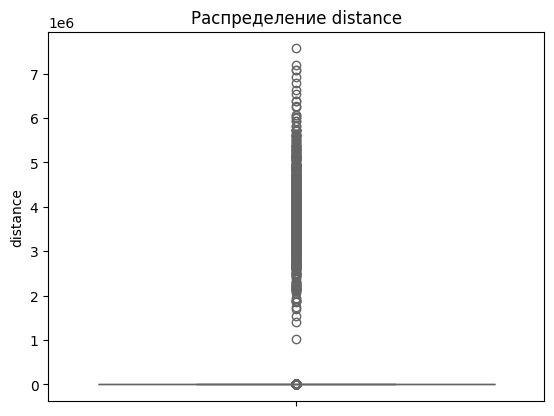

In [17]:
sns.boxplot(df_r, y='distance')
plt.title('Распределение distance')
plt.show()

Посмотрим наблюдения с большей distance. Пока вопросов не вызывает.

In [18]:
max_dist = df_r['distance'].max()
row = df_r.loc[df_r['distance'] == max_dist]
display(row.head())

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo
78664,175247,2023-07-10 09:57:49,2023-07-10 10:39:40,лесная,юго-восточный,березовая,северо-западный,7569789.0,1


### Пропуски и выбросы


Это отдельный блок, который посвящен вопросу с distance, так как много пропусков у в "end_date" нужно исследовать и понять как решить этот вопрос.

In [19]:
df_r.isna().sum()

id                   0
start_date           0
end_date           579
start_location       0
start_district       0
end_location         0
end_district         0
distance          1233
promo                0
dtype: int64

Можно подметить, что <u>мы имеем мало строк с пропуском конечной даты относительно кол-ва поездок</u>
Для предположения сколько ехал человек (end_date - start_date) <u>нужно знать среднюю скорость между точками
Но скорость не является постоянной в отличие от дистанции</u>, ведь зависит от множества факторов
Опытность пилота, характера вождения пилота, его целей на поездку
Также зависит от выбранного участка (его условий и нагруженности)
И естественно зависит от погоды.
**Исходя из вышесказанного**, можно подметить, что предусмотреть оптимальную замену пропуску не является возможным с нашим уровнем погружения.

In [20]:
df_r.dropna(subset=['end_date'], inplace=True)

 Попытаемся проанализировать возможные способы работы с пропусками для дистанции.

In [21]:
stats = (
    df_r.groupby(['start_location', 'end_location'])['distance']
    .agg(['min', 'max', 'median', 'mean', 'count'])
    .round(2)
)
stats['range'] = stats['max'] - stats['min']
stats = stats.sort_values('range', ascending=False)

print("Группы с наибольшим разрывом (min-max):")
print(stats.head(10))
# Уже заметно, что я обнаружил новый выброс

Группы с наибольшим разрывом (min-max):
                                   min        max  median       mean  count  \
start_location end_location                                                   
лесная         березовая        2896.0  7569789.0  4976.0  477831.25     16   
садовая        полевая             8.0  7204885.0  5442.5  405277.72     18   
рабочая        чкалова          3564.0  7073888.0  5209.0  888589.88     16   
московская     чкалова          3567.0  6914067.0  5679.0  633480.91     11   
лесная         новая            3125.0  6784244.0  5111.0  620914.45     11   
полевая        пионерская       1527.0  6627165.0  4944.5  225466.27     30   
пионерская     партизанская        3.0  6543723.0  4915.0  368048.89     18   
сиреневая      московская       4131.0  6377036.0  4936.0  854506.60     15   
красная        красноармейская     6.0  6263485.0  5180.0  630531.20     10   
мичурина       шоссейная        2964.0  6258726.0  5273.0  265647.58     24   

           

In [22]:
print(
    len(stats[stats['count'] < 50]), len(stats[stats['count'] >= 50])
)

8251 26


Невозможно адекватно определить выбросы.
Попытаемся проанализировать возможные способы работы с пропусками для дистанции, **возьмем по районам**.

In [23]:
stats_district = (
    df_r.groupby(['start_district', 'end_district'])['distance']
    .agg(['min', 'max', 'median', 'count'])
    .round(2)
)
stats_district['range'] = stats_district['max'] - stats_district['min']

print("Группы с наибольшим разрывом (min-max) по районам:")
print(stats_district)

Группы с наибольшим разрывом (min-max) по районам:
                                 min        max  median  count      range
start_district  end_district                                             
заречный        заречный         2.0  3878765.0  3005.0    937  3878763.0
                ленинский        3.0  7204885.0  5031.0   1509  7204882.0
                октябрьский      2.0  3491754.0  3513.0   1303  3491752.0
                северо-западный  3.0  5067538.0  4059.5   1510  5067535.0
                центральный      1.0  5648909.0  4011.0   2499  5648908.0
                юго-восточный    3.0  4527684.0  4011.5   1884  4527681.0
ленинский       заречный         2.0  6627165.0  5065.5   1540  6627163.0
                ленинский        2.0  4100201.0  3054.0   2586  4100199.0
                октябрьский      2.0  5165855.0  4053.0   2187  5165853.0
                северо-западный  2.0  4477585.0  3547.5   2596  4477583.0
                центральный      2.0  4868318.0  3519.5   405

In [24]:
print(
    len(stats_district[stats_district['count'] < 50]),
    len(stats_district[stats_district['count'] >= 50]),
)

0 36


Для таких групп, уже возможно выделение выбросов.

In [25]:
def fill_outliers_and_missing(group_cols, target_col):
    df_clean = df_r.copy()
    for name, group in df_r.groupby(group_cols):
        data = group[target_col].dropna()
        if len(data) > 0:
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            idx = group.index
            df_clean.loc[idx, target_col] = df_clean.loc[idx, target_col].fillna(
                data[(data >= lower) & (data <= upper)].median()
            )
            df_clean.loc[idx, target_col] = df_clean.loc[idx, target_col].clip(
                lower, upper
            )
    return df_clean


df_r = fill_outliers_and_missing(
    ['start_district', 'end_district'], 'distance'
)

Убираем выбросы по 1.5 * iqr и пропуски.

In [26]:
df_r.isna().sum()

id                0
start_date        0
end_date          0
start_location    0
start_district    0
end_location      0
end_district      0
distance          0
promo             0
dtype: int64

In [27]:
# Проверим
stats_district = (
    df_r.groupby(['start_district', 'end_district'])['distance']
    .agg(['min', 'max', 'median', 'count'])
    .round(2)
)
stats_district['range'] = stats_district['max'] - stats_district['min']

print(stats_district)  # Теперь лучше :)

                                     min      max  median  count   range
start_district  end_district                                            
заречный        заречный         1294.00  4670.00  3018.0    954  3376.0
                ленинский        1476.00  8420.00  5049.0   1530  6944.0
                октябрьский      1451.00  5563.00  3525.5   1320  4112.0
                северо-западный  1518.38  6609.38  4070.5   1524  5091.0
                центральный      1436.75  6610.75  4025.5   2530  5174.0
                юго-восточный    1512.50  6532.50  4022.0   1905  5020.0
ленинский       заречный         1716.75  8316.75  5088.0   1563  6600.0
                ленинский        1270.62  4829.62  3065.0   2615  3559.0
                октябрьский      1609.75  6495.75  4067.5   2210  4886.0
                северо-западный  1339.62  5676.62  3561.0   2624  4337.0
                центральный      1299.00  5771.00  3531.0   4098  4472.0
                юго-восточный    1381.62  6630.62  

**У нас получилось высчитать distance** благодаря подходу через районы, мы заполнили пропуски медианным значением, нам нужно было замерить расстоянием между районами, посмотреть медиану по ним, максимальное, минимальное, теперь данные выглядят адекватно - **вопрос решен!**

## Добавление итоговой_стоимости

В этом блоке нам нужно добавить фактор итоговой стоимости поездки, он зависит от 3 вещей:
- время, день (в разное время и дни, разная стоимость)
- длительность
- промокод (поездка может быть началась бесплатно по промокоду)

In [28]:
def get_rate(hour, weekday):
    is_weekend = weekday >= 5

    if 1 < hour < 6:
        return 3
    elif 5 < hour < 10:
        return 4
    elif 9 < hour < 16:
        return 6 if is_weekend else 5
    elif 15 < hour < 22:
        return 7 if is_weekend else 6
    elif hour > 21 or hour < 1:
        return 6 if is_weekend else 5
    else:
        return 0


def calc_cost(row):
    distance = row['distance']
    start = row['start_date']
    end = row['end_date']
    hour = start.hour
    weekday = start.weekday()
    duration = (end - start).total_seconds() / 60
    promo = row['promo']

    rate = get_rate(hour, weekday)

    base = 0 if promo else 30
    return base + duration * rate


df_r['total_cost'] = df_r.apply(calc_cost, axis=1)

## Добавление скорости

В этом блоке мы добавляем фактор скорость, для того чтобы в последующих действиях он фигурировал, как дополнительный фактор для анализа.

In [29]:
df_r['duration'] = df_r['end_date'] - df_r['start_date']

In [30]:
seconds = df_r['duration'].dt.total_seconds()
speed = round(df_r['distance'] / seconds, 3)
df_r['speed'] = speed
# добавляем фактор speed, где скорость измеряется в метрах на секунду

In [31]:
df_r.head()

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo,total_cost,duration,speed
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,124.800000,0 days 00:23:42,2.861
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,143.666667,0 days 00:28:25,2.648
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,183.266667,0 days 00:38:19,1.966
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,157.266667,0 days 00:31:49,2.033
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,152.666667,0 days 00:30:40,2.190


In [32]:
diff = (df_r['speed'] * df_r['duration'].dt.total_seconds() - df_r['distance']).abs()
diff.describe()

count    101676.000000
mean          0.397556
std           0.287758
min           0.000000
25%           0.176000
50%           0.350000
75%           0.560000
max           2.371000
dtype: float64

Узнав скорость можно посчитать дистанцию и сравнить с ранее посчитанной. Сравнили и получили что разницы почти нет, 2 метра максимум, но это совсем не критично, значит все верно.

# weather.csv

In [33]:
df_w = pd.read_csv(os.path.join(path, 'weather.csv'), sep=',', encoding='UTF-8')

## Предобработка данных

Здесь все также как и в прошлом файле, смотрим на типы данных, приводим названия к PEP-8.

In [34]:
df_w.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3673 entries, 0 to 3672
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Datetime             3672 non-null   object
 1   Temperature          3618 non-null   object
 2   Precipitation Total  3643 non-null   object
 3   Wind Gust            3673 non-null   object
 4   Wind Speed           3657 non-null   object
 5   Cloud Cover Total    3653 non-null   object
 6   Sunshine Duration    3661 non-null   object
dtypes: object(7)
memory usage: 201.0+ KB


### PEP-8 и типы данных

In [35]:
df_w.columns = df_w.columns.str.lower().str.replace(' ', '_')

In [36]:
df_w = df_w.drop(0)
df_w.head(5)  # строка с индексом 0 имеет записи об еденицах измерения, нужно её удалить - ,°C,mm,km/h,km/h,%,min

,datetime,temperature,precipitation_total,wind_gust,wind_speed,cloud_cover_total,sunshine_duration
1,2023-04-01T00:00:00,8.740245,0.1,48.6,21.638964,90,0
2,2023-04-01T01:00:00,9.040245,0.2,55.44,22.493519,74,0
3,2023-04-01T02:00:00,8.880245,0.3,55.8,22.26477,72,0
4,2023-04-01T03:00:00,8.690246,0.3,55.44,21.94524,77,0
5,2023-04-01T04:00:00,8.630245,0.3,48.96,22.42427,78,0


In [37]:
df_w['datetime'].unique()  # нам нужно поменять формат на datetime

array(['2023-04-01T00:00:00', '2023-04-01T01:00:00',
       '2023-04-01T02:00:00', ..., '2023-08-31T21:00:00',
       '2023-08-31T22:00:00', '2023-08-31T23:00:00'], dtype=object)

#### приведение типов данных

In [38]:
df_w['datetime'] = pd.to_datetime(df_w['datetime'])
df_w['temperature'] = df_w['temperature'].astype(
    float
)  # температура у нас не string а float должна быть
df_w['precipitation_total'] = df_w['precipitation_total'].astype(
    float
)  # тоже тип float потому что наблюдения: 1.9 (пример)
df_w['wind_gust'] = df_w['wind_gust'].astype(float)
df_w['wind_speed'] = df_w['wind_speed'].astype(float)
df_w['cloud_cover_total'] = df_w['cloud_cover_total'].astype(
    float
)  # на первый взгляд целочисленные, но там еще есть десятичные
df_w['sunshine_duration'] = df_w['sunshine_duration'].astype(
    float
)  # данные в вещественном формате

Получилось что почти все надо было исправить, типы данных не совпадают с наблюдениями, 0-ая строка наблюдения это единицы измерения, они нам не нужны там.

### Дубликаты

#### Явные дубликаты

In [39]:
df_w.duplicated().sum()  # явных дубликатов не обнаружено

np.int64(0)

Проверив наш датафрейм на явные дубликаты, мы ничего не нашли.

#### Неявные дубликаты

In [40]:
df_w['temperature'].unique()

array([ 8.740245,  9.040245,  8.880245, ..., 14.290245, 15.410245,
       19.980246])

Т. к. мы имеем дату, то ввиду отсутствия явных дубликатов и категориальных можно сделать вывод, что неявные дубликаты отсутствуют.

### Выбросы

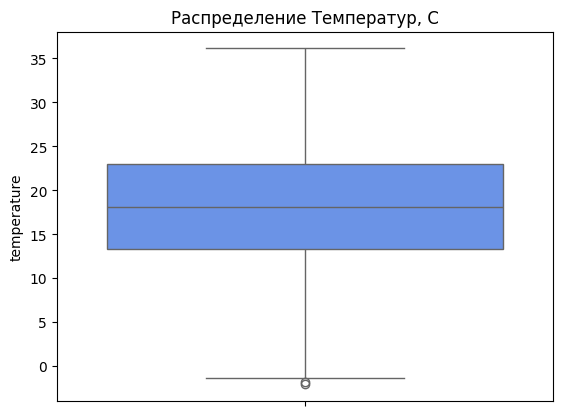

In [41]:
sns.boxplot(df_w, y='temperature')
plt.title('Распределение Температур, C')
plt.show()

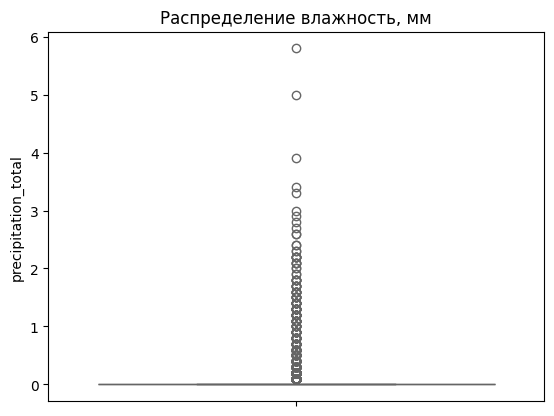

In [42]:
sns.boxplot(data=df_w, y='precipitation_total')
plt.title('Распределение влажность, мм')
plt.show()

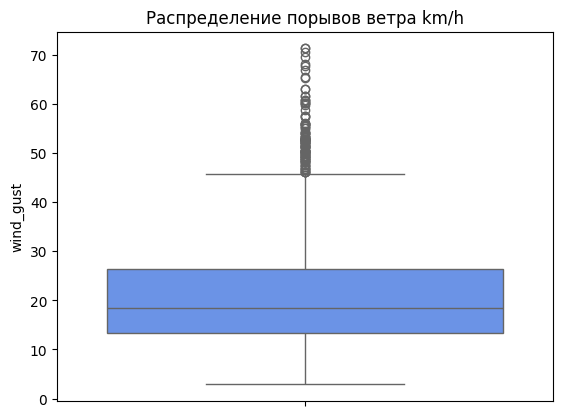

In [43]:
sns.boxplot(data=df_w, y='wind_gust')
plt.title('Распределение порывов ветра km/h')
plt.show()

Text(0.5, 1.0, 'Распределение скорости ветра, km/h')

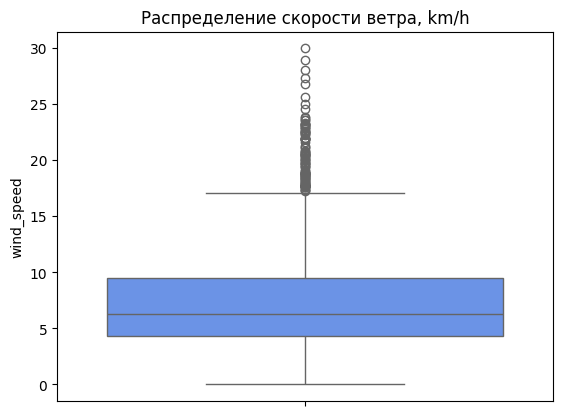

In [44]:
sns.boxplot(data=df_w, y='wind_speed')
plt.title('Распределение скорости ветра, km/h')

Считаю что в выбросах мы не можем утверждать об наблюдениях, которые нам нужно исправить, так как погода сама по себе бывает разная, но мы не нашли ошибок при получении данных, по крайней мере. Sunshine_duration - кол-во минут в часу, когда солнце светит, от 0 до 60, не вижу смылсла проверять на выбросы, их там не может быть, также как и в cloud_cover_total похожая ситуация: там в % от 0 до 100

### Пропуски

**Основная цель:** убрать пропуски, либо подставить значение, к примеру, медианное (или использовать интерполяцию), либо просто удалить пропуски.

In [45]:
df_w.isna().sum()

datetime                0
temperature            55
precipitation_total    30
wind_gust               0
wind_speed             16
cloud_cover_total      20
sunshine_duration      12
dtype: int64

Рассмотрим каждый фактор с пропусками детально, с графическим представлением.

In [46]:
def missing_all(col):
    df_w.isna().sum()
    plt.figure(figsize=(15, 5))
    missing_mask = df_w[col].isnull()
    plt.scatter(
        df_w.loc[~missing_mask, 'datetime'],
        df_w.loc[~missing_mask, col],
        c='blue',
        s=10,
        alpha=0.5,
        label='Есть данные',
    )
    plt.scatter(
        df_w.loc[missing_mask, 'datetime'],
        [0] * missing_mask.sum(),
        c='red',
        s=20,
        alpha=0.7,
        label='Пропуски',
        marker='x',
    )
    plt.title('Пропуски в столбце temperature', fontsize=14)
    plt.xlabel('Дата и время', fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

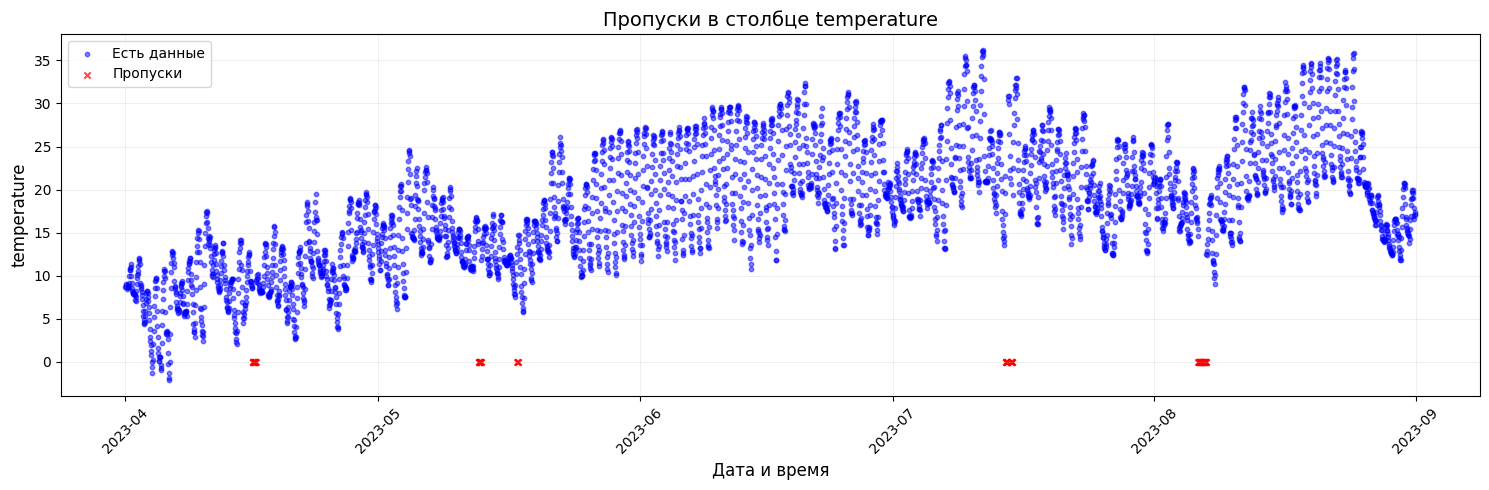

In [47]:
# Температура
missing_all('temperature')

Видно, что имеются группы выбросов. Далее детально рассматриваем каждую.

In [48]:
def missing_groups(column):
    missing = df_w[column].isnull()
    groups = []
    flag = None

    for i, is_miss in enumerate(missing):
        if is_miss and flag is None:
            flag = i
        elif not is_miss and flag is not None:
            groups.append((flag, i - 1))
            flag = None
    if flag is not None:
        groups.append((flag, len(missing) - 1))

    pad = len(groups)
    rows = (len(groups) + 1) // 2
    fig, axes = plt.subplots(rows, min(2, len(groups)), figsize=(15, 4 * rows))
    axes = [axes] if len(groups) == 1 else axes.flatten()

    for i, (s, e) in enumerate(groups):
        start_idx = max(0, s - pad)
        end_idx = min(len(df_w), e + pad)
        subset = df_w.iloc[start_idx:end_idx]

        axes[i].plot(
            subset['datetime'][subset[column].notna()],
            subset[column].dropna(),
            'o-',
            color='blue',
            markersize=3,
        )
        axes[i].axvspan(
            subset['datetime'].iloc[s - start_idx],
            subset['datetime'].iloc[e - start_idx],
            alpha=0.2,
            color='red',
        )
        axes[i].set_title(f'Группа {i + 1}: {e - s + 1} пропусков')
        axes[i].set_xlabel('Дата')
        axes[i].set_ylabel(column)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

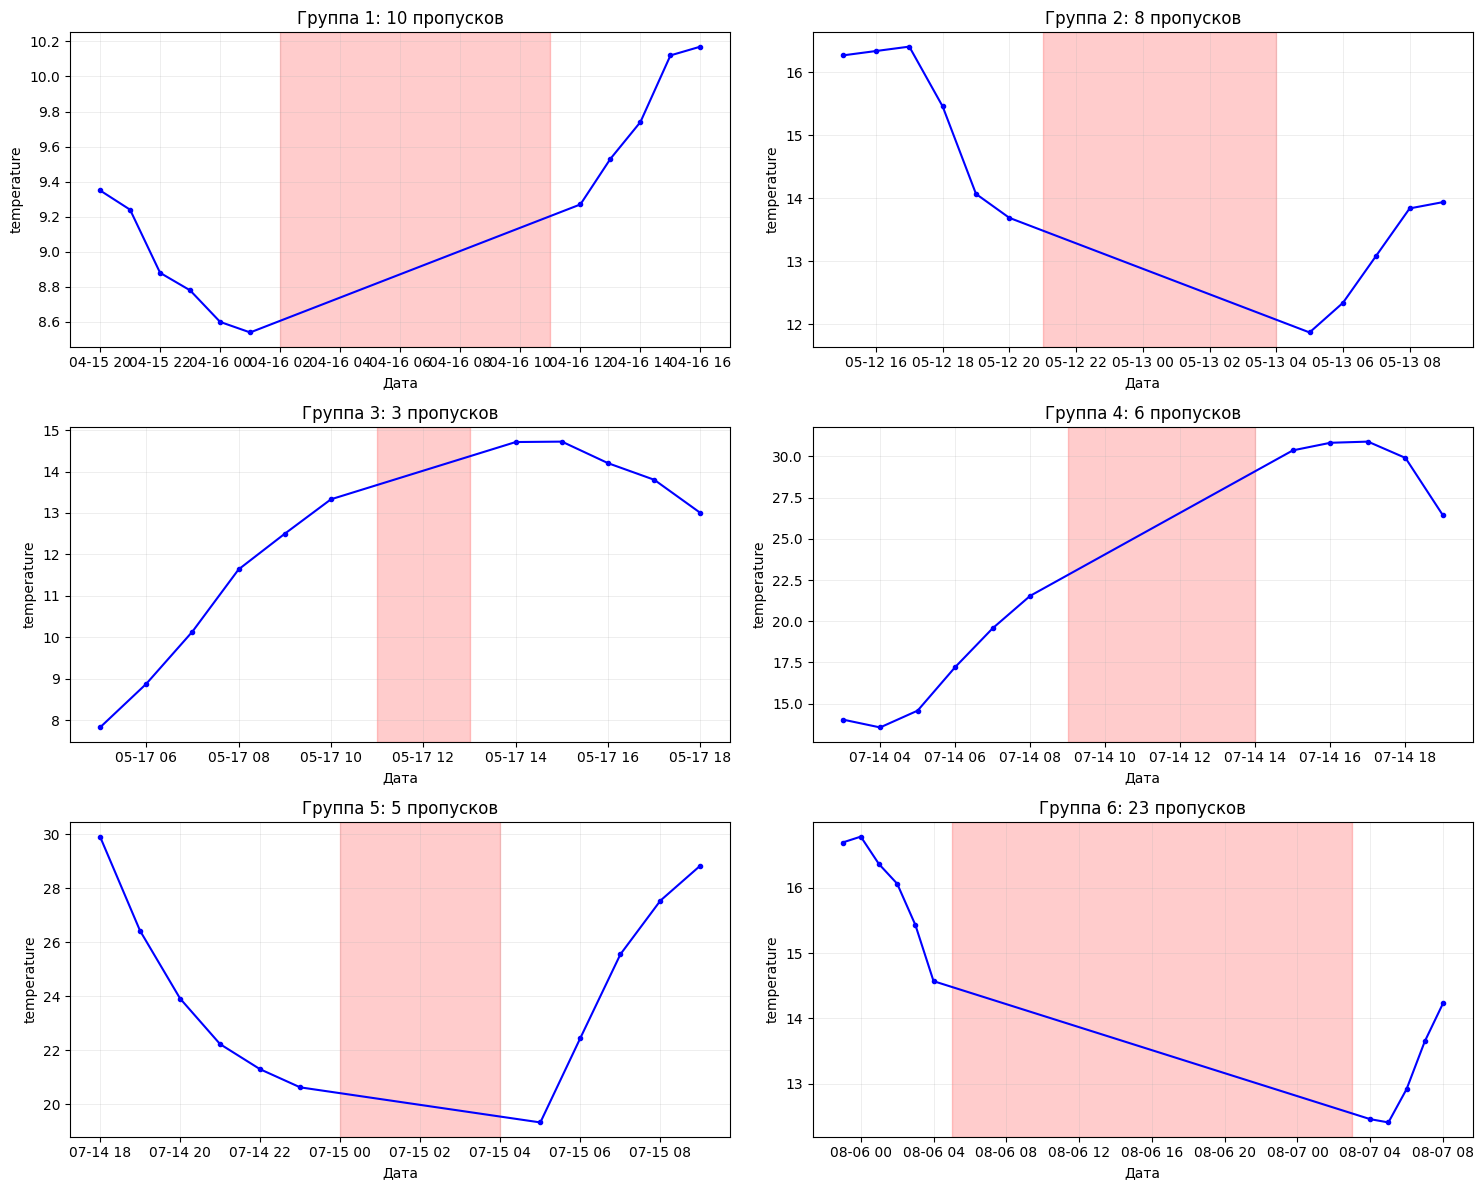

In [49]:
missing_groups(
    'temperature'
)

Видно трендовость пропусков по группам, значит заполнение интерполяцией будет оптимально.

In [50]:
df_w['temperature'] = df_w['temperature'].interpolate(
    method='linear', limit_direction='both'
)

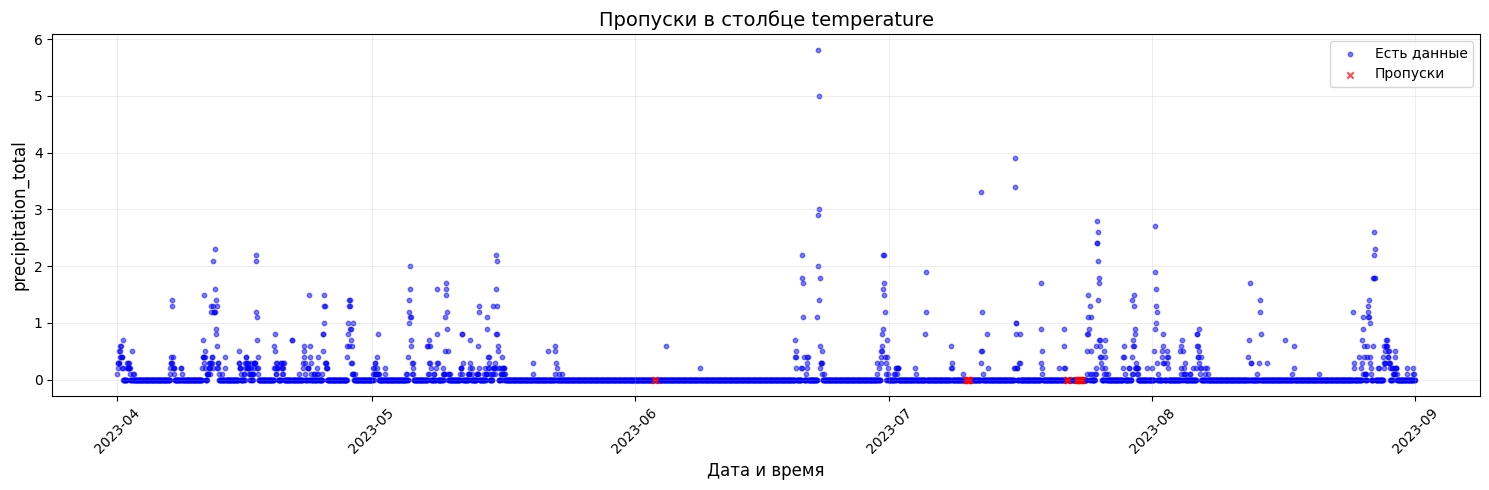

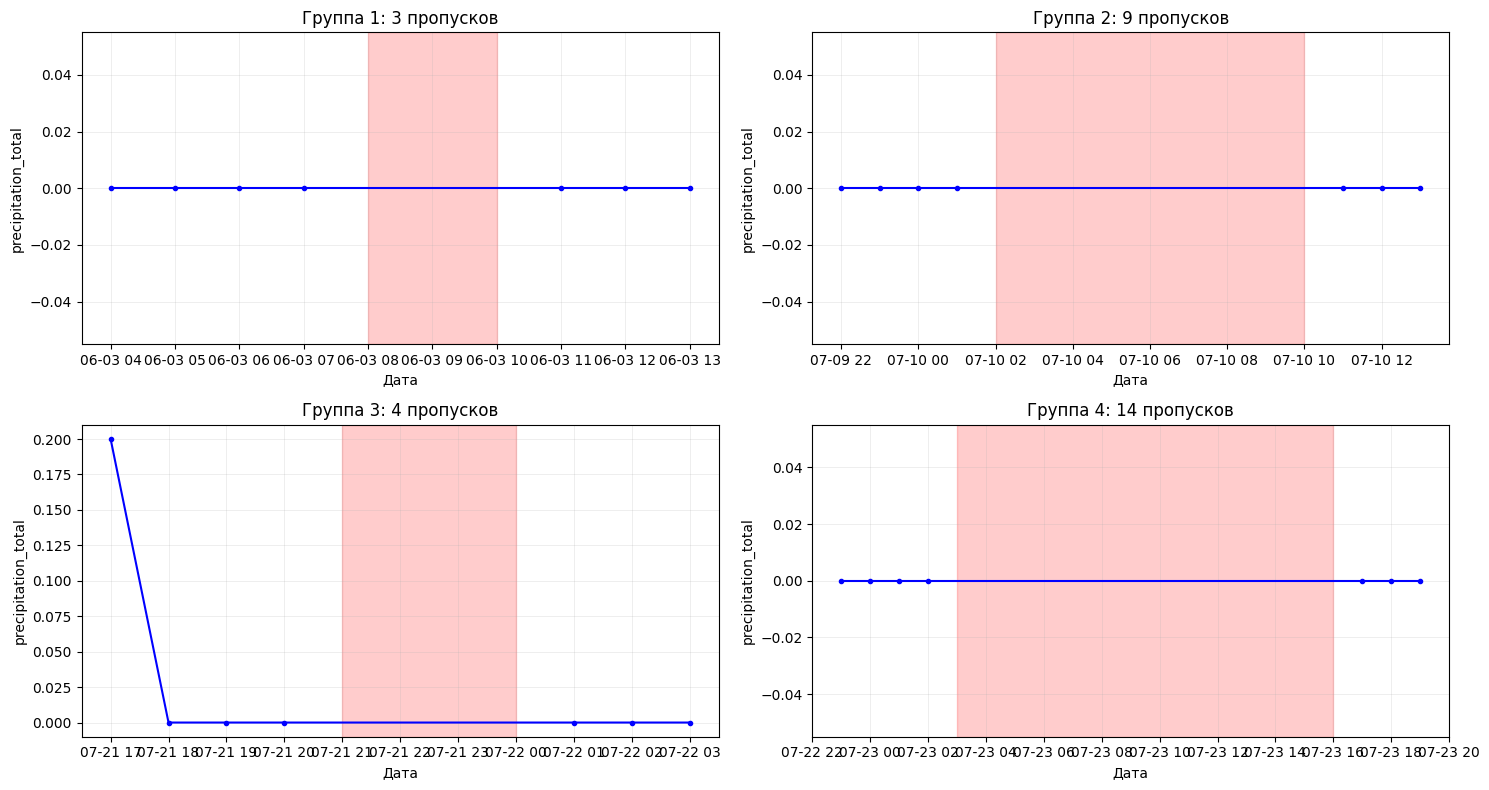

In [51]:
missing_all('precipitation_total')
missing_groups('precipitation_total')
# Аналогично температуре.

In [52]:
df_w['precipitation_total'] = df_w['precipitation_total'].interpolate(
    method='linear', limit_direction='both'
)

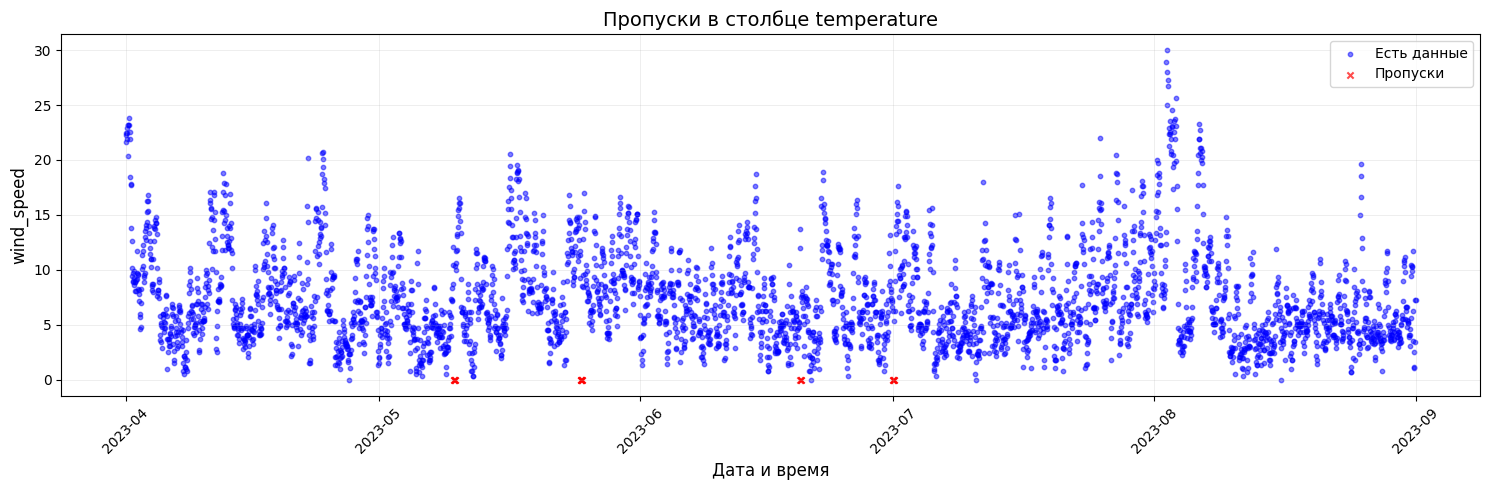

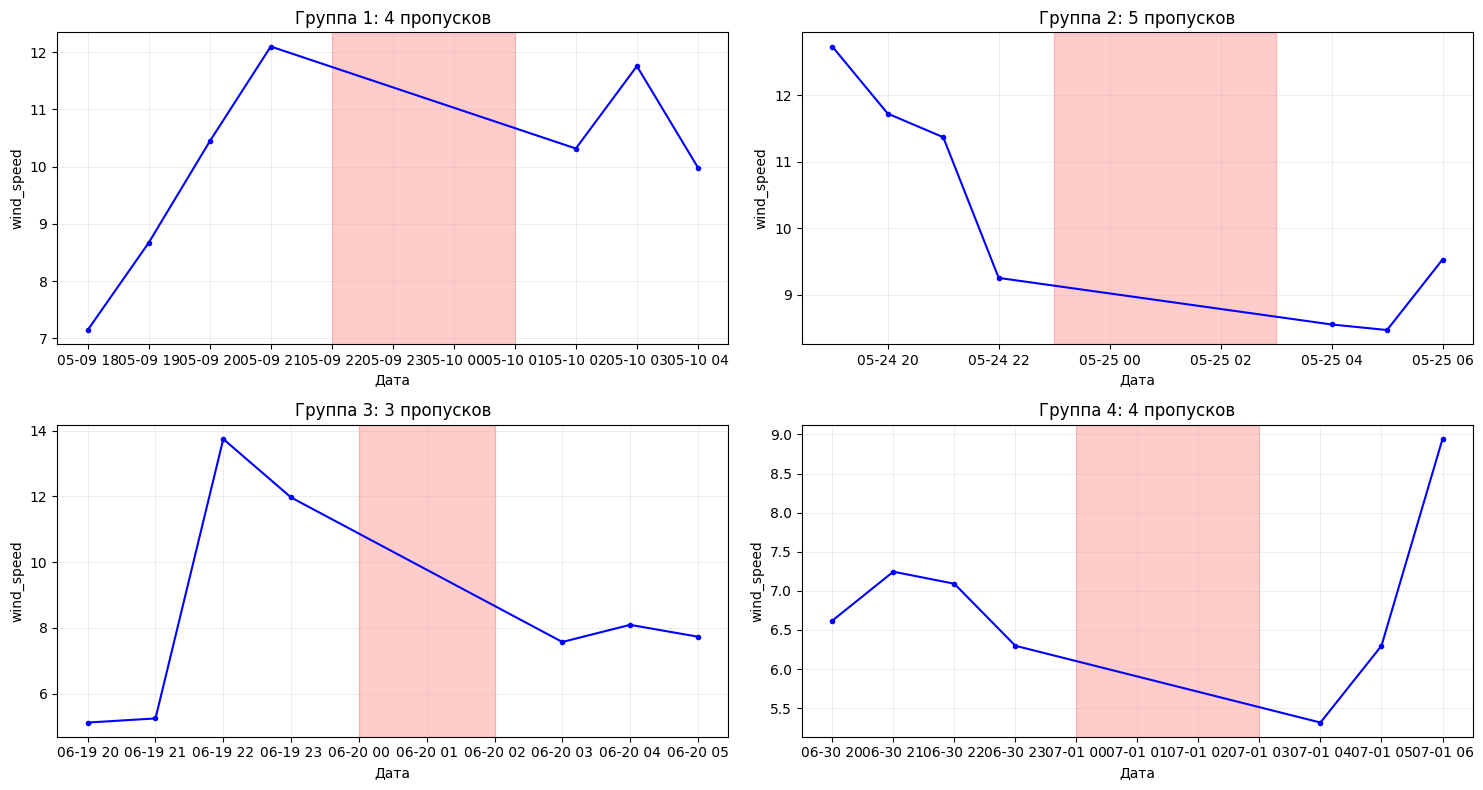

In [53]:
missing_all('wind_speed')
missing_groups('wind_speed')
# Аналогично предыдущим

In [54]:
df_w['wind_speed'] = df_w['wind_speed'].interpolate(
    method='linear', limit_direction='both'
)

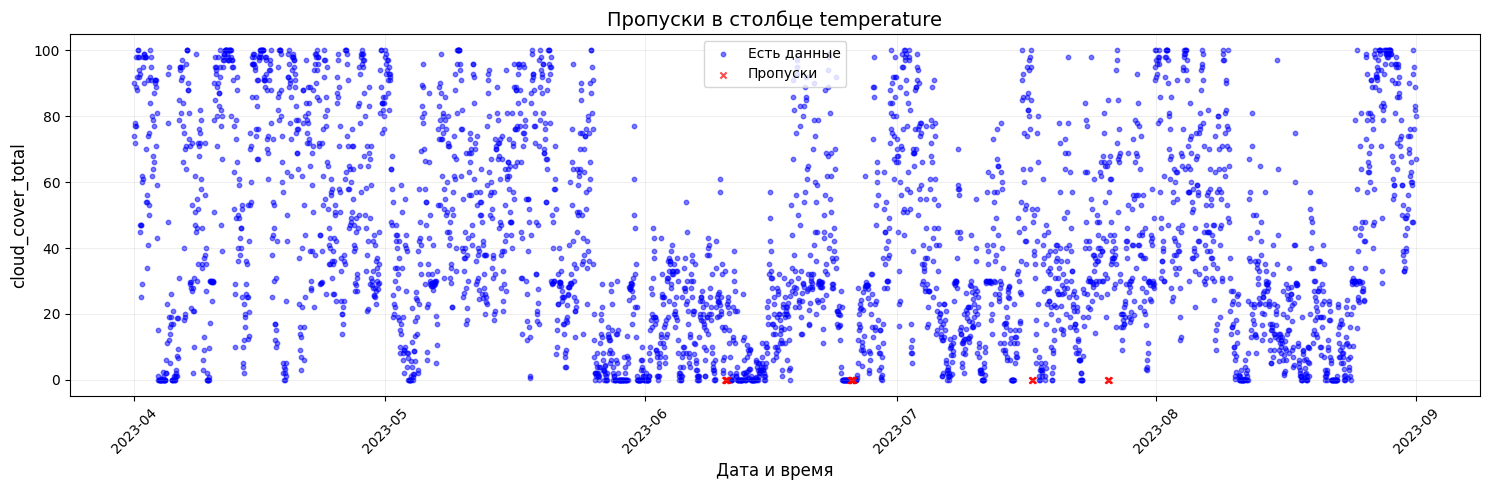

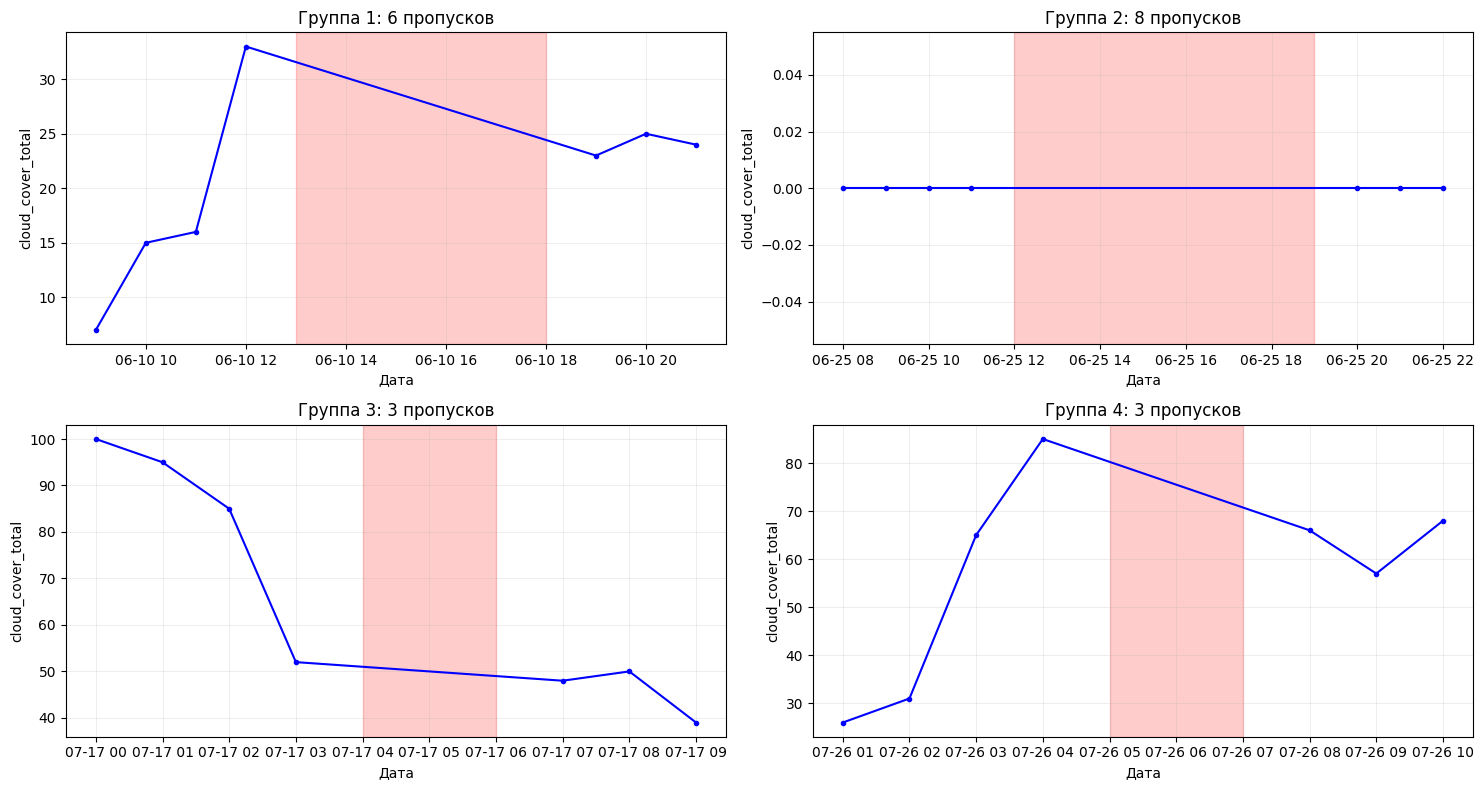

In [55]:
missing_all('cloud_cover_total')
missing_groups('cloud_cover_total')
# Аналогично предыдущим

In [56]:
df_w['cloud_cover_total'] = df_w['cloud_cover_total'].interpolate(
    method='linear', limit_direction='both'
)

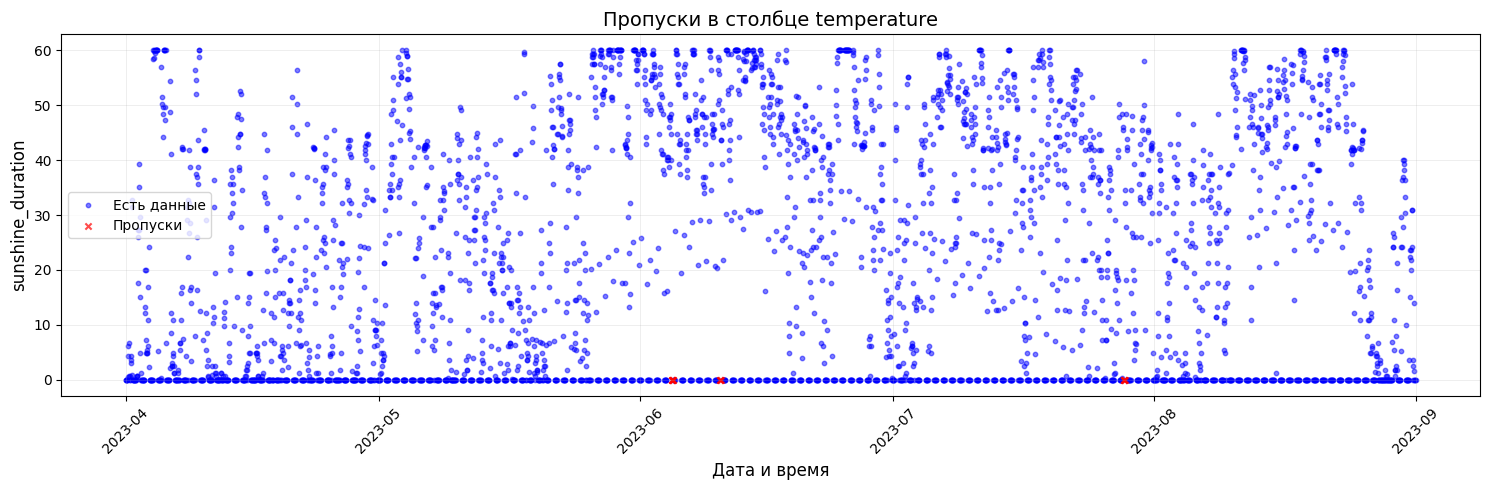

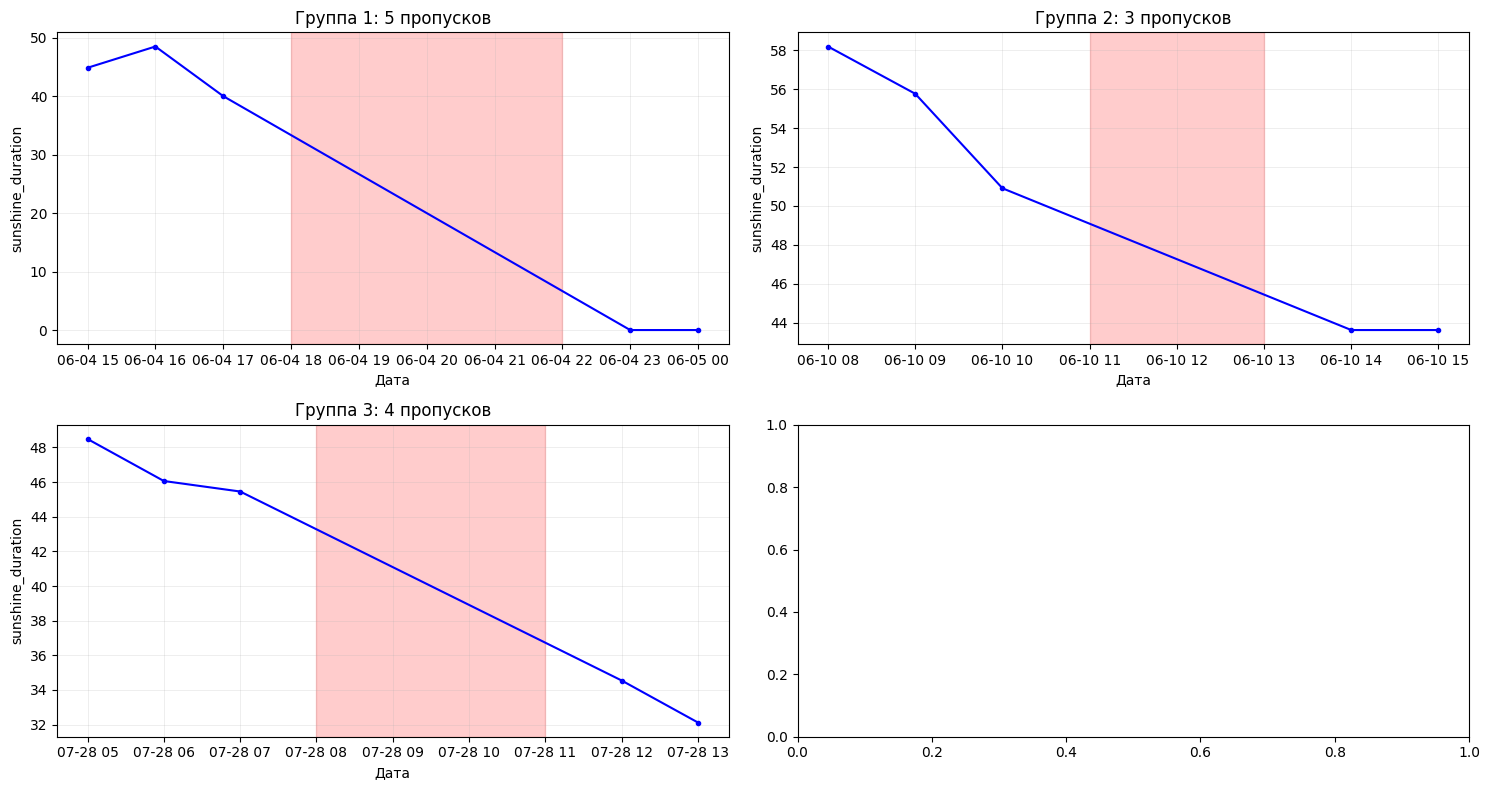

In [57]:
missing_all('sunshine_duration')
missing_groups('sunshine_duration')
# Аналогично предыдущим

In [58]:
df_w['sunshine_duration'] = df_w['sunshine_duration'].interpolate(
    method='linear', limit_direction='both'
)

Смею предположить, что происходили сбои в сборе определенного типа дынных. Они были относительно кратковременны. Мы обнаружили множество групп пропусков, заполнили пропуски методом интерполяции, так как посчитали что он будет оптимальным.

In [59]:
df_w.isna().sum()

datetime               0
temperature            0
precipitation_total    0
wind_gust              0
wind_speed             0
cloud_cover_total      0
sunshine_duration      0
dtype: int64

# Гипотезы

Гипотезы это то что поможет нам при анализе и укажет на какие факторы нужно ориентироваться потом. Нам нужно сперва понять что, дейстивительно, влияет на спрос. Для проверки гипотезы мы будем использовать 2 способа: статистический, графический, мы можем использовать и по 1 методу для гипотезы, если другой метод не представляется нужным для доказательства.

## Спрос в дождливые дни H1

- **H0**: спрос в дождливые дни не отличается.
- **H1**: спрос в дождливые дни выше.

мы должны взять похожие дни, один день дождливый, другой день обычный (например, понедельник и вторник дождливый)
возьмем некоторое количество пар, для более гарантированного исследования
думаю, что лучше написать функцию для того чтобы находить дождливые дни, одного дня недели

In [60]:
def search_rain_day(df_w, weekdays):
    df_daily = (
        df_w.groupby(df_w['datetime'].dt.floor('D'))
        .agg({'precipitation_total': 'sum'})
        .reset_index()
    )

    df_daily['weekday'] = df_daily['datetime'].dt.weekday

    pairs = []

    for weekday in weekdays:
        rainy_days = df_daily[
            (df_daily['weekday'].isin(weekdays)) & (df_daily['precipitation_total'] > 0)
        ]

        non_rainy_days = df_daily[
            (df_daily['weekday'].isin(weekdays))
            & (df_daily['precipitation_total'] == 0)
        ]

        for rain_day in rainy_days.itertuples():
            if not non_rainy_days.empty:
                non_rain_day = non_rainy_days.iloc[0]
                pairs.append(
                    {
                        'rainy_day': rain_day.datetime.date(),
                        'non_rain_day': non_rain_day.datetime.date(),
                    }
                )
                non_rainy_days = non_rainy_days.drop(non_rain_day.name)

    return pairs


def compare_demand(
    rides_df, rain_pairs
):  # соеденяем в датафрейм наблюдений из rides.csv
    demand_comparison = []

    for pair in rain_pairs:
        rainy_day = pair['rainy_day']
        non_rain_day = pair['non_rain_day']

        rainy_demand = rides_df[rides_df['start_date'].dt.date == rainy_day].shape[0]
        non_rainy_demand = rides_df[
            rides_df['start_date'].dt.date == non_rain_day
        ].shape[0]

        demand_comparison.append(
            {
                'rainy_day': rainy_day,
                'non_rain_day': non_rain_day,
                'rainy_demand': rainy_demand,
                'non_rainy_demand': non_rainy_demand,
            }
        )

    return pd.DataFrame(demand_comparison)


def test_normality(
    df_comparison,
):  # Проверка нормальности, выбор теста, также учитываем что выборки зависимые
    rainy_demand = df_comparison['rainy_demand']
    non_rainy_demand = df_comparison['non_rainy_demand']

    stat_rainy, p_rainy = shapiro(rainy_demand)
    stat_non_rainy, p_non_rainy = shapiro(non_rainy_demand)

    if p_rainy < 0.05 or p_non_rainy < 0.05:
        stat, p = ttest_ind(rainy_demand, non_rainy_demand)
    else:
        stat, p = mannwhitneyu(rainy_demand, non_rainy_demand)

    return stat, p


rain_pairs = search_rain_day(df_w, [0, 1, 2, 3, 4])
df_comparison = compare_demand(df_r, rain_pairs)

stat, p = test_normality(df_comparison)
print(stat, p)

-1.4083870094140778 0.15959411823126596


p-value < 0.05 соответственно, в будние дни(в выходные p-val=0.0002, если сравнивать отдельно - H1 тоже)
СТАТИСТИЧЕСКИ ЗНАЧИМО!

## Отличие ср.стоимости по районам H1

- **H0**: средняя стоимость по районам **не отличается.**
- **H1**: средняя стоимость по районам **отличается.** <br>
Что бы посчитать нам нужно сгруппировать по старту и по концу итоговую стоимость и что-то понять, доказать.

In [61]:
def compare_mean_cost(df_r):
    districts = df_r['start_district'].unique().tolist()

    results = []

    for i in range(len(districts)):
        for j in range(i + 1, len(districts)):
            a1 = districts[i]
            a2 = districts[j]

            price_1 = df_r[df_r['start_district'] == a1]['total_cost']
            price_2 = df_r[df_r['start_district'] == a2]['total_cost']

            mean_1 = price_1.mean()
            mean_2 = price_2.mean()

            stat, p = mannwhitneyu(price_1, price_2)

            results.append(
                {
                    'district_1': a1,
                    'district_2': a2,
                    'mean_1': mean_1,
                    'mean_2': mean_2,
                    'p-value': round(p, 4),
                    'result': 'H1' if p < 0.05 else 'H0',
                }
            )

    results_df = pd.DataFrame(results)
    print(results_df)


compare_mean_cost(
    df_r
)

         district_1       district_2      mean_1      mean_2  p-value result
0     юго-восточный         заречный  181.984658  185.194013   0.0000     H1
1     юго-восточный      октябрьский  181.984658  171.250060   0.0000     H1
2     юго-восточный      центральный  181.984658  172.632686   0.0000     H1
3     юго-восточный  северо-западный  181.984658  185.184167   0.0000     H1
4     юго-восточный        ленинский  181.984658  176.625699   0.0000     H1
5          заречный      октябрьский  185.194013  171.250060   0.0000     H1
6          заречный      центральный  185.194013  172.632686   0.0000     H1
7          заречный  северо-западный  185.194013  185.184167   0.1854     H0
8          заречный        ленинский  185.194013  176.625699   0.0000     H1
9       октябрьский      центральный  171.250060  172.632686   0.0016     H1
10      октябрьский  северо-западный  171.250060  185.184167   0.0000     H1
11      октябрьский        ленинский  171.250060  176.625699   0.0000     H1

Видим что у всех райнов, кроме 1 пары отличается стоимость - **принимаем H1: Средняя стоимость по райнонам различается** - СТАТИСТИЧЕСКИ ЗНАЧИМО!

## Спрос на самокаты дни недели H1

- **H0**: спрос не меняется с днем недели.
- **H1**: спрос меняется с днем недели.

Считаю что в этой гипотезе мы будем использовать 2 метода проверки гипотезы: графический и статистический, потому что графическим мы сначала можем понять имеет ли смысл проверять статистикой, оно нам покажет наглядно распределение спроса по каждому из дней недели, статистически мы докажем саму value.

### Графически

In [62]:
def how_much_on_day(df_r, weekdays):
    result = {}
    for weekday in weekdays:
        result[weekday] = (df_r['start_date'].dt.weekday == weekday).sum()
    return result


num = how_much_on_day(df_r, [0, 1, 2, 3, 4, 5, 6])

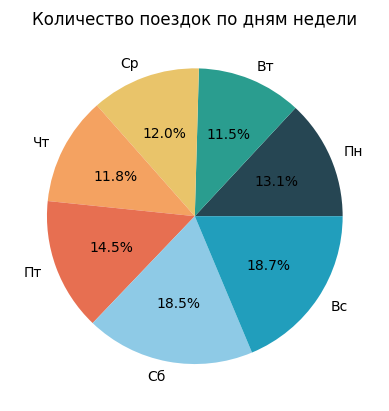

In [63]:
values = list(num.values())
colors = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51', '#8ECAE6', '#219EBC']
plt.pie(
    values,
    labels=['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'],
    autopct='%1.1f%%',
    colors=colors,
)
plt.title('Количество поездок по дням недели')
plt.show()


Анализирую график можно сказать что в выходные спрос выше(сб:18,5; вс:18,7) затем по спросу пт(14,5) пн(13,1) ср(12) чт(11,8) вт(11,5). Пока что все очевидно и наглядно, докажем и статистически

### Статистически

In [64]:
daily_data = pd.DataFrame(
    {'date': df_r['start_date'].dt.date, 'weekday': df_r['start_date'].dt.weekday}
)

daily_rides = (
    daily_data.groupby(['date', 'weekday']).size().reset_index(name='ride_count')
)

day_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
daily_rides['weekday_name'] = daily_rides['weekday'].map(day_names)


def analyze_demand_by_day(daily_rides):
    groups = []
    day_labels = []

    for day in range(7):
        day_data = daily_rides[daily_rides['weekday'] == day]['ride_count']

        groups.append(day_data)
        day_labels.append(day)
        print(
            f"День {day} ({day_names[day]}): {len(day_data)} дней, среднее = {day_data.mean():.1f} поездок в день"
        )

    h_stat, p_value = kruskal(*groups)

    print(f"\np-value = {p_value:.5f}")
    if p_value < 0.05:
        print("Статистически значимые различия между днями недели обнаружены")
    else:
        print("Статистически значимых различий между днями недели нет")


analyze_demand_by_day(daily_rides)

День 0 (Пн): 15 дней, среднее = 886.3 поездок в день
День 1 (Вт): 14 дней, среднее = 833.9 поездок в день
День 2 (Ср): 14 дней, среднее = 868.6 поездок в день
День 3 (Чт): 14 дней, среднее = 860.3 поездок в день
День 4 (Пт): 14 дней, среднее = 1053.0 поездок в день
День 5 (Сб): 15 дней, среднее = 1251.3 поездок в день
День 6 (Вс): 15 дней, среднее = 1266.1 поездок в день

p-value = 0.00000
Статистически значимые различия между днями недели обнаружены


В результате: **H1**. Мы отвергли нулевую гипотезу, проверив графически и статистически, так что, действительно, спрос меняется в зависимости от дня недели

## Выходные поездки длиннее? H1

- **H0**: в выходные поездки не длиннее.
- **H1**: в выходные поездки длиннее.

In [65]:
daily_data['duration'] = df_r['end_date'] - df_r['start_date']
daily_data['date'] = pd.to_datetime(daily_data['date'])

In [66]:
daily_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101676 entries, 0 to 102254
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype          
---  ------    --------------   -----          
 0   date      101676 non-null  datetime64[ns] 
 1   weekday   101676 non-null  int32          
 2   duration  101676 non-null  timedelta64[ns]
dtypes: datetime64[ns](1), int32(1), timedelta64[ns](1)
memory usage: 6.7 MB


In [67]:
def compare_duration(data):
    weekdays = data.loc[data['weekday'].isin([0, 1, 2, 3, 4])].copy()  # Будние дни
    weekends = data.loc[data['weekday'].isin([5, 6])].copy()  # Выходные дни

    weekdays['duration_minutes'] = weekdays['duration'].dt.total_seconds() / 60
    weekends['duration_minutes'] = weekends['duration'].dt.total_seconds() / 60

    norm_1 = normaltest(weekdays['duration_minutes'])
    norm_2 = normaltest(weekends['duration_minutes'])

    if norm_1.pvalue > 0.05 and norm_2.pvalue > 0.05:
        stat = ttest_ind(weekdays['duration_minutes'], weekends['duration_minutes'])
        print(
            'ttest_ind',
            (
                f'H1, {stat.pvalue:.4f}'
                if stat.pvalue < 0.05
                else f'H0, {stat.pvalue:.4f}'
            ),
        )
    else:
        stat = mannwhitneyu(weekdays['duration_minutes'], weekends['duration_minutes'])
        print(
            'mannwhitneyu',
            f'H1, {stat.pvalue}' if stat.pvalue < 0.05 else f'H0, {stat.pvalue}',
        )


compare_duration(
    daily_data
)

mannwhitneyu H1, 1.3143939462485257e-195


В результате: p-value очень маленькое, следовательно: **H1** - в выходные поездки длиннее. Различия СТАТИСТИЧЕСКИ ЗНАЧИМЫЕ!

## В будние поездки скоростнее H1

- **H0**: в выходные дни поездки скоростнее.
- **H1**: в будние дни поездки скоростнее.

Чтобы провести проверку этой гипотезы нам нужно сначала сделать 2 выборки:
1) Взять **клиентов в будние** дни и посчитать среднюю скорость.
2) Взять **клиетов в выходные** дни и посчитать среднюю скорость.

In [68]:
daily_rides['speed'] = df_r['speed']

In [69]:
def compare_speed_weekdays(df_r):
    weekday = df_r['weekday'].isin([0, 1, 2, 3, 4])
    weekend = df_r['weekday'].isin([5, 6])

    stat_1, p_1 = normaltest(weekday)
    stat_2, p_2 = normaltest(weekend)

    if p_1 > 0.05 and p_2 > 0.05:
        stat, p = ttest_ind(weekday, weekend)
        method = 'ttest_ind'
    else:
        stat, p = mannwhitneyu(weekday, weekend)
        method = 'mannwhitneyu'

    print(f'{method}, стат.данные: {stat}, p-value: {p}')
    print('H1' if {round(p, 4) < 0.05} else 'H0')


compare_speed_weekdays(
    daily_rides
)# Получается что, мы отвергаем H0 и принимаем H1, различия СТАТИСТИЧЕСКИ ЗНАЧИМЫЕ!

mannwhitneyu, стат.данные: 7171.0, p-value: 8.725349738459153e-09
H1


Мы **отвергаем H0 и принимаем H1**, следовательно: **в будние дни поездки скоростнеe.**

## Спрос из-за промокода повышается H0

Здесь интересная гипотеза, потому что мы можем отталкиваясь от нее понимать, можем ли мы влиять на спрос по средствам ценообразования, монипулируя ценой повышать спрос

- **H0**: **спрос** из-за промокода **не повышается**.
- **H1**: **спрос** из-за промокода **повышается**.

Чтобы проверить гипотезу нам нужно разделить выборки на дни в которых был промокод и похожие дни. Промокод у нас действует только утром в понедельник, значит мы должны брать максимально похожий день, например, вторник, потому что это тоже будний день.

In [70]:
df_w_p = df_w[
    ['datetime', 'precipitation_total', 'wind_gust', 'sunshine_duration', 'temperature']
].copy()

df_w_p['promo'] = df_r['promo']
df_w_p['start_date'] = df_r['start_date']

In [71]:
def find_promo_demand(d_w_p):

    conditions = (
        (d_w_p['precipitation_total'] == 0)
        & (d_w_p['wind_gust'] < 30)
        & (d_w_p['sunshine_duration'] < 10)
        & (d_w_p['temperature'] < 22)
    ) # проверяем чтобы другие факторы были усредненными, не вызывали помех при доказательстве

    d_rides = d_w_p.groupby('start_date').size().reset_index(name='rides_count')
    d_w_p = d_w_p.merge(d_rides, on='start_date', how='left')

    promo = d_w_p.loc[conditions & (d_w_p['promo'] == 1)]
    non_promo = d_w_p.loc[
        conditions & (d_w_p['promo'] == 0) & (d_w_p['start_date'].dt.weekday == 1)
    ]

    promo_data = promo['rides_count']
    non_promo_data = non_promo['rides_count']

    shap_1 = shapiro(promo_data)
    shap_2 = shapiro(non_promo_data)

    if shap_1.pvalue > 0.05 and shap_2.pvalue > 0.05:
        stat, p = ttest_ind(promo_data, non_promo_data)
        method = 'ttest_ind'
    else:
        stat, p = mannwhitneyu(promo_data, non_promo_data)
        method = 'mannwhitneyu'

    alpha = 0.05
    hypothesis = (
        'H1 (есть статистически значимая разница)'
        if p < alpha
        else 'H0 (нет статистически значимой разницы)'
    )
    print(f"Метод: {method}")
    print(f"p-значение: {round(p, 4)}")
    print(f"Вывод: {hypothesis}")
    print(
        f"Размер промо-группы: {len(promo_data)}, не-промо группы: {len(non_promo_data)}"
    )


find_promo_demand(
    df_w_p
)  # (пытался увеличивать выборку наблюдений, p-val только увеличивалось), значит действительно H0

Метод: mannwhitneyu
p-значение: 0.6464
Вывод: H0 (нет статистически значимой разницы)
Размер промо-группы: 16, не-промо группы: 194


При проверке гипотезы мы опровергли H1, исходя из этого: промокод не влияет на спрос, значит мы не можем манипулировать ценой, в целях прибавки спроса. Размер групп я специально проверял, так как думал что это выборка не репрезентативная и не может быть точно из-за своего маленького размера, но все тчетно, p-value только увеличивается

## Если солнечно - спрос увеличивается H0

- **H0**: Солнечная погода не влияет на спрос.
- **H1**: Солнечная погода влияет на спрос.

Здесь все аналогично, берем две выборки: интересующую и не интересующую

In [72]:
def find_sunshine_demand(d_w_p):
    conditions = (
        (d_w_p['precipitation_total'] == 0)
        & (d_w_p['wind_gust'] < 30)
        & (d_w_p['temperature'] < 22)
        & (d_w_p['start_date'].dt.weekday.isin([5, 6]))
    )

    d_rides = d_w_p.groupby('start_date').size().reset_index(name='rides_count')
    d_w_p = d_w_p.merge(d_rides, on='start_date', how='left')

    sun_day = d_w_p.loc[conditions & (d_w_p['sunshine_duration'] > 35)]
    non_sun_day = d_w_p.loc[conditions & (d_w_p['sunshine_duration'] < 10)]

    sun_data = sun_day['rides_count'].dropna()
    non_sun_data = non_sun_day['rides_count'].dropna()

    shap_1 = shapiro(sun_data)
    shap_2 = shapiro(non_sun_data)

    if shap_1.pvalue > 0.05 and shap_2.pvalue > 0.05:
        stat, p = ttest_ind(sun_data, non_sun_data)
        method = 'ttest_ind'
    else:
        stat, p = mannwhitneyu(sun_data, non_sun_data)
        method = 'mannwhitneyu'

    alpha = 0.05
    hypothesis = (
        'H1 (есть статистически значимая разница)'
        if p < alpha
        else 'H0 (нет статистически значимой разницы)'
    )
    print(f"Метод: {method}")
    print(f"p-значение: {round(p, 4)}")
    print(f"Вывод: {hypothesis}")
    print(
        f"Размер солнечной группы: {len(sun_data)}, несолнечной группы: {len(non_sun_data)}"
    )


find_sunshine_demand(df_w_p)

Метод: mannwhitneyu
p-значение: 0.2547
Вывод: H0 (нет статистически значимой разницы)
Размер солнечной группы: 278, несолнечной группы: 674


Мы приняли гипотезу **H0: солце не влияет на спрос.**

## Скорость в дождливую погоду выше H0

- **H0**: дождь не влияет на скорость.
- **H1**: дождь влияет на скорость.

Мне кажется что скорость является фактором, который может демонстрировать нам как сильно клиенты спешат, если они спешат достаточно сильно, то они готовы потратить деньги на электросамокаты, но это может быть не актуально если клиенты, к примеру, заказывают такси чтобы доехать с комфортом, но я думаю что на электросамокате можно быстрее добраться по городу от точки A до точки B.

In [73]:
df_w_p['speed'] = df_r['speed']
df_w_p.head()

,datetime,precipitation_total,wind_gust,sunshine_duration,temperature,promo,start_date,speed
1,2023-04-01 00:00:00,0.1,48.60,0.0,8.740245,0.0,2023-04-22 09:01:07,2.648
2,2023-04-01 01:00:00,0.2,55.44,0.0,9.040245,0.0,2023-04-22 09:04:27,1.966
3,2023-04-01 02:00:00,0.3,55.80,0.0,8.880245,0.0,2023-04-22 09:06:34,2.033
4,2023-04-01 03:00:00,0.3,55.44,0.0,8.690246,0.0,2023-04-22 09:09:27,2.190
5,2023-04-01 04:00:00,0.3,48.96,0.0,8.630245,0.0,2023-04-22 09:10:09,2.044


In [74]:
df_w_p['precipitation_total'].describe()

count    3672.000000
mean        0.100218
std         0.342384
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         5.800000
Name: precipitation_total, dtype: float64

In [75]:
def find_speed_rain_demand(d_w_p):
    conditions = (
        (d_w_p['wind_gust'] < 30)
        & (d_w_p['sunshine_duration'] < 15)
        & (d_w_p['temperature'] < 22)
        & (d_w_p['start_date'].dt.weekday.isin([2, 3, 4]))
    )

    d_rides = d_w_p.groupby('start_date').size().reset_index(name='rides_count')
    d_w_p = d_w_p.merge(d_rides, on='start_date', how='left')

    rain_day = d_w_p.loc[conditions & (d_w_p['precipitation_total'] > 0)]
    non_rain_day = d_w_p.loc[conditions & (d_w_p['precipitation_total'] == 0)]

    rain_data = rain_day['rides_count'].dropna()
    non_rain_data = non_rain_day['rides_count'].dropna()

    shap_1 = shapiro(rain_data)
    shap_2 = shapiro(non_rain_data)

    if shap_1.pvalue > 0.05 and shap_2.pvalue > 0.05:
        stat, p = ttest_ind(rain_data, non_rain_data)
        method = 'ttest_ind'
    else:
        stat, p = mannwhitneyu(rain_data, non_rain_data)
        method = 'mannwhitneyu'

    alpha = 0.05
    hypothesis = (
        'H1 (есть статистически значимая разница)'
        if p < alpha
        else 'H0 (нет статистически значимой разницы)'
    )
    print(f"Метод: {method}")
    print(f"p-значение: {round(p, 4)}")
    print(f"Вывод: {hypothesis}")
    print(
        f"Размер дождливой группы: {len(rain_data)}, не дождливой группы: {len(non_rain_data)}"
    )


find_speed_rain_demand(df_w_p)

Метод: mannwhitneyu
p-значение: 0.73
Вывод: H0 (нет статистически значимой разницы)
Размер дождливой группы: 56, не дождливой группы: 85


Мы принимаем гипотезу **H0: дождь не влияет на скорость.**

## Скорость выше когда сильные порывы ветра H0

- **H0**: порывы ветра **не влияют на скорость.**
- **H1**: порывы ветра **влияют на скорость.**

In [76]:
df_w_p['wind_gust'].describe() # нам важно понять при каких значениях порыва ветра он будет влиять, возьмем 75 процентиль

count    3672.000000
mean       20.886568
std        10.436531
min         2.880000
25%        13.320000
50%        18.359999
75%        26.280000
max        71.280000
Name: wind_gust, dtype: float64

In [77]:
def find_speed_windgust_demand(d_w_p):
    conditions = d_w_p['start_date'].dt.weekday.isin([2, 3, 4])

    d_rides = d_w_p.groupby('start_date').size().reset_index(name='rides_count')
    d_w_p = d_w_p.merge(d_rides, on='start_date', how='left')

    gust_day = d_w_p.loc[conditions & (d_w_p['wind_gust'] > 26)]
    non_gust_day = d_w_p.loc[conditions & (d_w_p['wind_gust'] < 26)]

    gust_data = gust_day['rides_count'].dropna()
    non_gust_data = non_gust_day['rides_count'].dropna()

    if len(gust_data) < 3:
        print(
            "Ошибка: в группе с сильным ветром меньше 3 наблюдений. Анализ невозможен."
        )
        print(f"Размер ветреной группы: {len(gust_data)}")
        return

    if len(non_gust_data) < 3:
        print(
            "Ошибка: в группе без сильного ветра меньше 3 наблюдений. Анализ невозможен."
        )
        print(f"Размер не ветреной группы: {len(non_gust_data)}")
        return

    if len(gust_data) == 0 or len(non_gust_data) == 0:
        print("Ошибка: одна из групп пуста. Анализ невозможен.")
        print(
            f"Размер ветреной группы: {len(gust_data)}, не ветреной группы: {len(non_gust_data)}"
        )
        return

    shap_1 = shapiro(gust_data)
    shap_2 = shapiro(non_gust_data)

    alpha = 0.05
    if shap_1.pvalue > alpha and shap_2.pvalue > alpha:
        stat, p = ttest_ind(gust_data, non_gust_data)
        method = 'ttest_ind'
    else:
        stat, p = mannwhitneyu(gust_data, non_gust_data)
        method = 'mannwhitneyu'

    hypothesis = (
        'H1 (есть статистически значимая разница)'
        if p < alpha
        else 'H0 (нет статистически значимой разницы)'
    )
    print(f"Метод: {method}")
    print(f"p-значение: {round(p, 4)}")
    print(f"Вывод: {hypothesis}")
    print(
        f"Размер ветреной группы: {len(gust_data)}, не ветреной группы: {len(non_gust_data)}"
    )


find_speed_windgust_demand(df_w_p)

Метод: mannwhitneyu
p-значение: 0.6511
Вывод: H0 (нет статистически значимой разницы)
Размер ветреной группы: 35, не ветреной группы: 292


Принимаем гипотезу **H0: порывы ветра не влияют на скорость**. Думаю что теория о том что скорость может иметь подсмысл описанный выше (см. описание к гипотизе "Скорость в дождливую погоду выше")

## Длительность выше когда ясная погода H0

- **H0**: **длительность поездки не меняется** от ясной погоды.
- **H1**: **длительность поездки больше** когда ясная погода.

In [78]:
df_w_p['sunshine_duration'].describe()

count    3672.000000
mean       21.541568
std        21.884632
min         0.000000
25%         0.000000
50%        15.151516
75%        42.545456
max        60.000000
Name: sunshine_duration, dtype: float64

In [79]:
def find_fineweather_demand(d_w_p):
    conditions = (
        (d_w_p['start_date'].dt.weekday.isin([2, 3, 4]))
        & (d_w_p['wind_gust'] < 26)
        & (d_w_p['precipitation_total'] == 0)
    )

    d_rides = d_w_p.groupby('start_date').size().reset_index(name='rides_count')
    d_w_p = d_w_p.merge(d_rides, on='start_date', how='left')

    shiny_day = d_w_p.loc[conditions & (d_w_p['sunshine_duration'] > 40)]
    non_shiny_day = d_w_p.loc[conditions & (d_w_p['sunshine_duration'] < 15)]

    shiny_data = shiny_day['rides_count'].dropna()
    non_shiny_data = non_shiny_day['rides_count'].dropna()

    shap_1 = shapiro(shiny_data)
    shap_2 = shapiro(non_shiny_data)

    if shap_1.pvalue > 0.05 and shap_2.pvalue > 0.05:
        stat, p = ttest_ind(shiny_data, non_shiny_data)
        method = 'ttest_ind'
    else:
        stat, p = mannwhitneyu(shiny_data, non_shiny_data)
        method = 'mannwhitneyu'

    alpha = 0.05
    hypothesis = (
        'H1 (есть статистически значимая разница)'
        if p < alpha
        else 'H0 (нет статистически значимой разницы)'
    )
    print(f"Метод: {method}")
    print(f"p-значение: {round(p, 4)}")
    print(f"Вывод: {hypothesis}")
    print(
        f"Размер ясной группы: {len(shiny_data)}, не ветреной группы: {len(non_shiny_data)}"
    )


find_fineweather_demand(df_w_p)

Метод: mannwhitneyu
p-значение: 0.1023
Вывод: H0 (нет статистически значимой разницы)
Размер ясной группы: 71, не ветреной группы: 111


Принимаем **H0: ясная погода не влияет на длительность поездки.**

## Вечерний спрос выше H1

- **H0**: вечером **такой же спрос.**
- **H1**: вечерний **спрос выше.** <div>
 Здесь мы можем понять что час пик вечером, спрос там будет выше чем обычно.

In [80]:
df_r['hour'] = df_r['start_date'].dt.hour


def get_time_of_day(hour):
    if 5 <= hour <= 11:
        return 'morning'
    elif 12 <= hour <= 17:
        return 'afternoon'
    elif 18 <= hour <= 23:
        return 'evening'
    else:
        return 'night'


df_r['time_of_day'] = df_r['hour'].apply(get_time_of_day)
hourly_demand = df_r.groupby(['hour', 'time_of_day']).size().reset_index(name='demand')
evening = hourly_demand[hourly_demand['time_of_day'] == 'evening']['demand']
other = hourly_demand[hourly_demand['time_of_day'] != 'evening']['demand']
# Мы используем разбивку на 6 часов, значит нет возможности проверить на нормальность.
stat, p = mannwhitneyu(evening, other, alternative='greater')

print(f'mannwhitneyu, stat: {stat}, p-value: {p}')
print(
    'H1 (есть статистически значимая разница)'
    if p < 0.05
    else 'H0 (нет статистически значимой разницы)'
)

mannwhitneyu, stat: 91.0, p-value: 0.005921424113643793
H1 (есть статистически значимая разница)


Мы принимаем гипотезу **H1: вечером спрос выше**, это означает что вечером час пик и спрос растет.

## Эффект выходных сильнее, чем эффект погоды

Здесь мы сравниваем разные эффекты в выходные дни и в будние

In [81]:
df_r['date'] = df_r['start_date'].dt.date
df_w['date'] = df_w['datetime'].dt.date

df_w_daily = df_w.groupby('date').mean().reset_index()
df_rid = df_r.groupby('date').size().reset_index(name='rides')
df = df_w_daily.merge(df_rid, on='date')
df['weekend'] = pd.to_datetime(df['date']).dt.dayofweek.isin([5, 6])
cols = df_w.columns[1:7]
for col in cols:
    med = df[col].median()
    w = df[df['weekend']]
    d = df[~df['weekend']]
    _, p1 = mannwhitneyu(w[w[col] > med]['rides'], w[w[col] <= med]['rides'])
    _, p2 = mannwhitneyu(d[d[col] > med]['rides'], d[d[col] <= med]['rides'])

    if p1 < 0.05 and p2 < 0.05:
        print(f"{col}: влияет всегда")
    elif p1 < 0.05:
        print(f"{col}: влияет только в выходные")
    elif p2 < 0.05:
        print(f"{col}: влияет только в будни")
    else:
        print(f"{col}: не влияет")

temperature: влияет всегда
precipitation_total: влияет только в выходные
wind_gust: влияет только в будни
wind_speed: не влияет
cloud_cover_total: влияет всегда
sunshine_duration: влияет всегда


Исключу факторы которые влияют всегда.
 - **Влияют только в будние**: wind_gust
 - **Влияют только в выходные**: precipitation_total.

# Вывод по гипотезам

На какие факторы мы можем ориенитроваться, когда нам нужно предсказывать спрос:
- Дождь
- День недели
- Часы <div>

**Дождь**. Мы приняли H1: что спрос в дождливое вермя действително возрастает, нужно это учитывать. <div>
**День недели**. В разные дни недели разный спрос, мы принимали гипотезу что спрос разлечается в разные дни недели, а также что в выходные больше спроса. <div>
**Часы**. Нужно учитывать что есть час-пики, в например, утром в будний день и вечером.

Также:
1) Также мы поняли что мы не можем манипулировать спросом за счет ценообразования (промокодами).
2) Средняя итоговая_стоимость по районам различается.
3) В выходные дни поездки длиннее.
4) В будние поездки скоростнее.

# Модель

## Создаем датафрейм для модели

Нам нужно создать модель линейной регрессии, которая будет учитывать что нам нужно,
а нам нужно учитывать: час суток, сколько было тогда клиетнов, был ли дождь, день недели, какой
промежуток дня

In [82]:
df_w.loc[(df_w['precipitation_total']) > 0 & (df_w['precipitation_total'] < 0.03)].count()
# Зачем нам знать это? Дождь начинается с 0.5 - 0.7 мм, но это же не отменяет тот факт что при маленьком
# моросящем дождике люди хотят взять самокат, чтобы сократить время прибывания на улице, поэтому сделаем
# границу, при переводе этот фактор в бинарный, x > 0, просто чтобы предсказывать что кол-во клиентов
# увеличится за счет даже маленьких осадков

datetime               676
temperature            676
precipitation_total    676
wind_gust              676
wind_speed             676
cloud_cover_total      676
sunshine_duration      676
date                   676
dtype: int64

In [83]:
df_m = pd.DataFrame(df_w['datetime'])
df_m['rain'] = df_w['precipitation_total'].apply(lambda x: 1 if x > 0 else 0)
df_m['time_of_day'] = df_w['datetime'].dt.hour.apply(get_time_of_day)
df_m['weekday'] = df_m['datetime'].dt.weekday
df_m['hour'] = df_m['datetime'].dt.hour
df_m['is_weekend'] = df_m['datetime'].dt.weekday.isin([5, 6]).astype(int)

In [84]:
if 'riders_per_hour' in df_m.columns: # добавляем кол-во клиентов за час
    df_m.drop('riders_per_hour', axis=1, inplace=True)

df_r['start_date'] = pd.to_datetime(df_r['start_date'])
df_m['datetime'] = pd.to_datetime(df_m['datetime'])

df_r['date_hour'] = df_r['start_date'].dt.floor('h')

riders_per_hour = df_r.groupby('date_hour').size().reset_index(name='riders_per_hour')

df_m['datetime_hour'] = df_m['datetime'].dt.floor('h')

df_m = df_m.merge(
    riders_per_hour,
    left_on='datetime_hour',
    right_on='date_hour',
    how='left'
)

df_m['riders_per_hour'] = df_m['riders_per_hour'].fillna(0).astype(int)
df_m.drop(['datetime_hour', 'date_hour'], axis=1, inplace=True)

In [85]:
df_m['riders_per_hour'].unique() # думаю что все ок

array([  0,  21,  43,  30,  51,  50,  67,  64,  97,  71, 110, 106, 103,
       104,  41,  15,   8,   4,   2,   6,  14,  33,  32,  29,  40,  65,
        48,  89, 105,  74,  72,  92,  70,  69,  27,   5,   1,  23,  34,
        25,  19,  47,  98,  55,  73,  46,  26,  31,  22,  24,  39,  79,
        45,  13,  38,  28,  20,  59,   7,  36,  37,  77,  57,  58,  42,
        18,   3,  35,  53, 111,  86,  78,  81,  12,  54,  90, 120,  82,
       129,  60, 108,  17,   9,  96,  75,  10,  56,  63,  49,  44,  52,
       119,  62,  80, 153, 109, 107, 122,  61, 112, 102,  16,  84,  95,
        11,  68,  87,  99,  76, 100,  66,  91, 116,  85, 162, 117, 113,
       156, 132, 124, 139,  83, 101,  93,  94, 136, 127, 125, 126,  88,
       123, 142, 115, 128, 121, 114, 180, 138, 131, 130, 145, 118, 137,
       146, 157, 165, 134])

In [86]:
if 'datetime' in df_m.columns:
    df_m.drop('datetime', axis=1, inplace=True)

теперь нам нужно сделать лаговые, например, спрос час назад. Лаговые помогут понимать модели больше датафрейм и плавнее делать придикты, но важно чтобы созданные лаговые не имели мультиколлениварость (в превой версии этого раздела так и было, я создал много лаговых, которые переобучили модель, что вызвало много проблем).

In [87]:
df_m['lag_1'] = df_m['riders_per_hour'].shift(1) # показывает какой спрос был 1 час назад
df_m['rolling_168h'] = df_m['riders_per_hour'].rolling(window=168).mean()
# С помощью скользящего среднего можно отделить устойчивый рост спроса от случайных наплывов и чётко увидеть тренд

## Создаем модель

In [88]:
df_m['time_of_day'].unique()

array(['night', 'morning', 'afternoon', 'evening'], dtype=object)

In [89]:
encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df_m[['time_of_day']])
feature_names = encoder.get_feature_names_out(['time_of_day'])
encoded_df_m = pd.DataFrame(encoded, columns=feature_names, index=df_m.index)

In [90]:
X = pd.concat([df_m[[
    'rain', 'weekday', 'hour', 'lag_1', 'rolling_168h'
]], encoded_df_m], axis=1)
y = df_m['riders_per_hour']

# а еще нам нужно преобразовать фактор "time_of_day" в бинарный encoder-ом, потому что модель не может работать с текстом

In [91]:
X_clean = X.dropna()
y_clean = y.loc[X_clean.index]

Получилась мультиколлениарность при вводе многих факторов, в большенстве из-за лаговых (демонстрация мультиколлениарности)
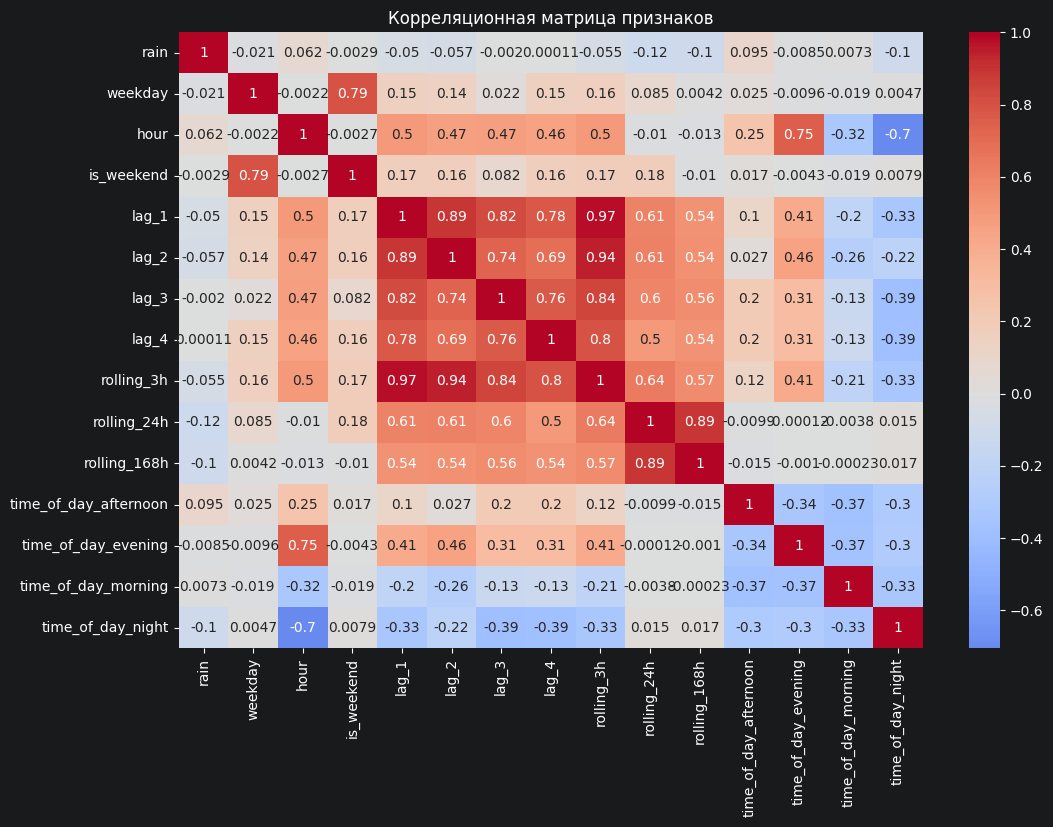

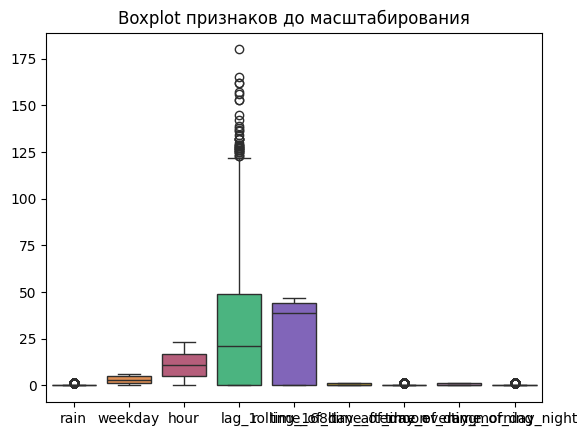

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

scaler = StandardScaler()

sns.boxplot(data=X_train)
plt.title("Boxplot признаков до масштабирования")
plt.show()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

predict = model.predict(X_test_scaled)

In [93]:
r2 = r2_score(y_test, predict)
mae = mean_absolute_error(y_test, predict)

r2 = round(r2, 2)
mae = round(mae, 2)
print(r2, mae) # до маштабироавния было mae 8.82

0.85 8.8


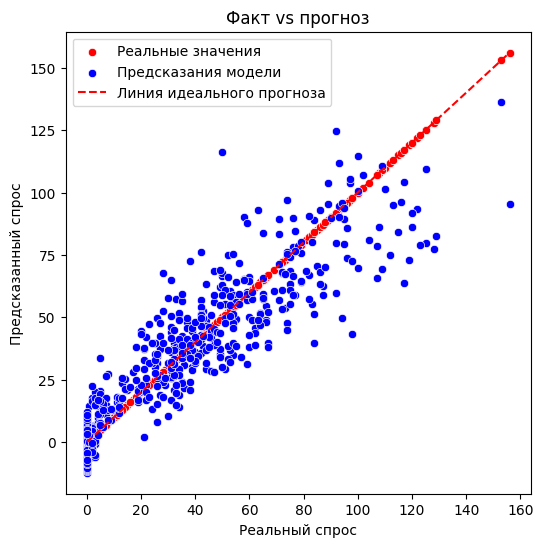

In [94]:
plt.figure(figsize=(6,6))

sns.scatterplot(x=y_test, y=y_test, color='red', label='Реальные значения')

sns.scatterplot(x=y_test, y=predict, color='blue', label='Предсказания модели')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Линия идеального прогноза')

plt.xlabel("Реальный спрос")
plt.ylabel("Предсказанный спрос")
plt.title("Факт vs прогноз")
plt.legend()
plt.show()

Видим что предсказания работают в пределах допустимой нормы, но чем больше реальные значения, тем больше разброс предиктов

In [95]:
coefs = model.coef_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs
}).sort_values(by='Coefficient', ascending=False)

print(importance_df) # Смотрим важность факторов для модели

                 Feature  Coefficient
3                  lag_1    26.349408
5  time_of_day_afternoon     4.374796
4           rolling_168h     3.682532
6    time_of_day_evening     3.565755
1                weekday     1.205340
0                   rain    -0.822872
7    time_of_day_morning    -1.044242
2                   hour    -6.837864
8      time_of_day_night    -7.262432


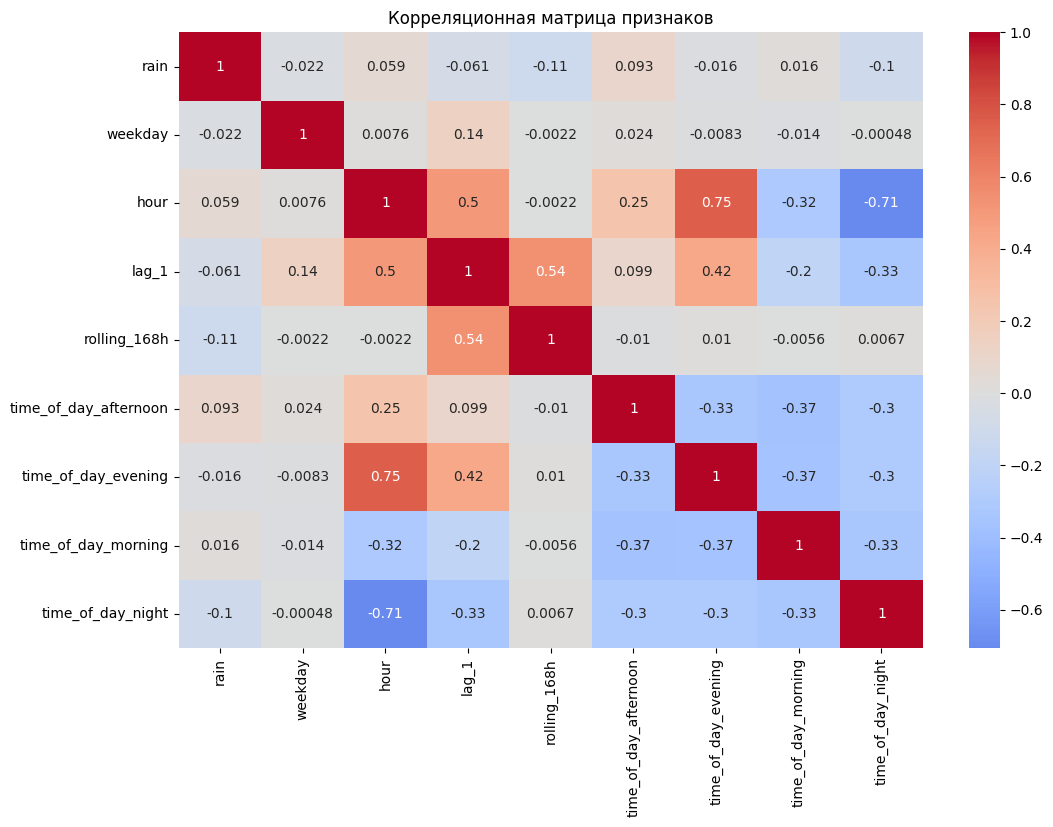

In [96]:
corr_matrix = X_train.corr()

# Визуализируем
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Корреляционная матрица признаков')
plt.show()

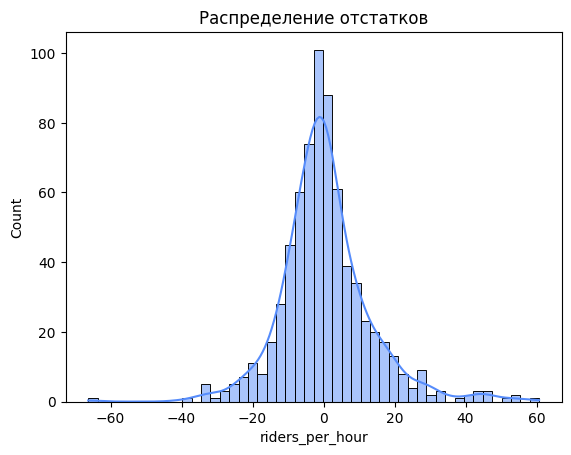

In [98]:
errors = y_test - predict
sns.histplot(errors, kde=True)
plt.title('Распределение отстатков')
plt.show()

Можем увидеть размах насколько наша модель может ошибаться, остатки.

## Вывод по модели

1) Модель объясняет 85% вариации данных (R² = 0.85), что является хорошим результатом для этой задачи.
2) Хотя средняя абсолютная ошибка (MAE) составляет около 9, что на первый взгляд не так уж много, можно заметить, что модель имеет трудности с предсказанием больших значений спроса. Это приводит к увеличению разброса ошибок на этих данных.
3) Визуализация остатков показывает, что в целом ошибки модели имеют нормальное распределение, но на больших значениях наблюдается увеличение разброса.
4) Выбросы на графике также требуют внимания. Нужно провести дополнительный анализ остатков, чтобы понять, можно ли их исключить или обработать. <div>

В целом модель может работать нормально, но нужно делать акцент на большом количестве спроса, там могут быть ошибки, разброс предсказываемых значений.